# Chapter 6 Auto Regressive models and Transformers

1. Understand what is an **auto-regressive** model 
2. Describe bow **RNN** work
3. Undestand the concept of **LSTM** and its **limitations**
4. Describe the **basic ideas** behind a **Transformer** architecture
5. **Byte-level BPE** tokenization (learn merges from raw UTF‑8 bytes)
6. **Decoder-only Transformer** with **causal self-attention**
7. A small **train/evaluate/generate** loop on a simple corpus (Tiny Shakespeare)
8. A **worked attention example** showing the actual $QK^\top$ scores, causal masking, and the softmax weights


## License

**Text, figures, and explanations:**  
© 2026 Imran Zualkernan. Licensed under **CC BY 4.0**.

**Code cells:**  
© 2026 Imran Zualkernan. Licensed under the **MIT License**.

You are free to reuse, modify, and redistribute with attribution.

## Autoregressive Models

An **autoregressive (AR)** model defines a probability distribution over a sequence by factorizing it into a product of **next-step conditionals**.

Let a sequence be $x_{1:T} = (x_1,\dots,x_T)$. The autoregressive factorization is:

$$
p(x_{1:T}) = \prod_{t=1}^{T} p(x_t \mid x_{1:t-1}).
$$

For language modeling with tokens $s_t \in \{1,\dots,V\}$:

$$
p(s_{1:T}) = \prod_{t=1}^{T} p(s_t \mid s_{<t}),
\quad
p(s_t \mid s_{<t}) = \text{Categorical}(\pi_t),
\quad
\pi_t = \text{softmax}(z_t).
$$

$
s_t \sim \mathrm{Categorical}(\pi_t)
$

means:

$
\Pr(s_t = i \mid s_{<t}) = \pi_{t,i}
\quad \text{for } i=1,\dots,V. 
$

where $V$ is the vocabulary (all tokens).

So

$
p(s_t \mid s_{<t}) = \mathrm{Categorical}(\pi_t)
$

is shorthand for “the conditional distribution of the next token is categorical with parameter $pi_t$.” So the $Categorical$ may give us the next probably word, for example. 

**Two distinct stages** always exist:

- **Training (teacher forcing):** you condition on the *ground-truth* prefix $x_{<t}$ to predict $x_t$.
- **Sampling (generation):** you condition on the *model’s own previously generated* samples.

## Simple Autoregressive Example: Predicting the Next Digit (0/1) in a Pattern

We build a tiny **autoregressive** (AR) model over binary digits.

Let the sequence be:

$$
x_{1:T}, \quad x_t \in \{0,1\}.
$$

The **autoregressive factorization** is:

$$
p(x_{1:T}) = \prod_{t=1}^{T} p(x_t \mid x_{1:t-1}).
$$

### A patterned dataset

Consider a deterministic pattern that alternates:

$$
0,1,0,1,0,1,\dots
$$

So the rule is:

- if the last digit is $0$, the next is $1$
- if the last digit is $1$, the next is $0$

Formally, for $t \ge 2$:

$$
x_t = 1 - x_{t-1}.
$$

### A simple autoregressive model for next-digit prediction

Assume our model only looks at the **most recent digit** (a 1-step Markov AR model):

$$
p_\theta(x_t \mid x_{1:t-1}) = p_\theta(x_t \mid x_{t-1}).
$$

We represent the probability of $x_t=1$ using a sigmoid:

$$
p_\theta(x_t = 1 \mid x_{t-1}) = \sigma(w\,x_{t-1} + b),
$$

and therefore:

$$
p_\theta(x_t = 0 \mid x_{t-1}) = 1 - \sigma(w\,x_{t-1} + b).
$$

Define:

$$
\hat{p}_t := p_\theta(x_t = 1 \mid x_{t-1}) = \sigma(w x_{t-1} + b).
$$

A Bernoulli distribution with parameter $p$ has:

- $P(X=1) = p$
- $P(X=0) = 1-p$

We want **one formula** that works for both outcomes $x \in \{0,1\}$.

That standard Bernoulli PMF is:

$$
P(X=x) = p^x (1-p)^{1-x}.
$$

Therefore, the likelihood for the observed binary target $x_t$ is:

$$
p_\theta(x_t \mid x_{t-1})
=
\hat{p}_t^{x_t}(1-\hat{p}_t)^{(1-x_t)}.
$$

### Training stage (teacher forcing)

Given a training sequence (e.g., $0,1,0,1,0,1$), we minimize the negative log-likelihood:

$$
\mathcal{L}(\theta)
=
-\sum_{t=2}^{T} \log p_\theta(x_t \mid x_{t-1}).
$$

This becomes the standard binary cross-entropy:

$$
\mathcal{L}(\theta)
=
-\sum_{t=2}^{T}
\Big[
x_t \log(\hat{p}_t) + (1-x_t)\log(1-\hat{p}_t)
\Big].
$$

**Teacher forcing means:** when predicting $x_t$, we condition on the **true** previous digit $x_{t-1}$ from the dataset.

### Sampling stage (generation)

To generate a new sequence, choose a starting digit $x_1$ (seed), then repeatedly sample:

1. Compute
   $$
   \hat{p}_t = \sigma(w x_{t-1} + b)
   $$
2. Sample
   $$
   x_t \sim \text{Bernoulli}(\hat{p}_t)
   $$
3. Append $x_t$ and continue

For example, if the model learned the alternating pattern well:

- start with $x_1 = 0$
- it produces $x_2 \approx 1, x_3 \approx 0, x_4 \approx 1,\dots$

### What makes this “autoregressive”?

At generation time, the model’s prediction of $x_t$ is conditioned on **previous generated digits**:

$$
x_{t-1} \rightarrow \hat{p}_t \rightarrow x_t,
$$

so the sequence is produced **one step at a time**, always using the past as context. In this example, the context size is **one** because we only look at the digit that came before. In general, we could look at a larger **context window** but this is not necessary in this case. 

## Recurrent Neural Networks (RNNs)

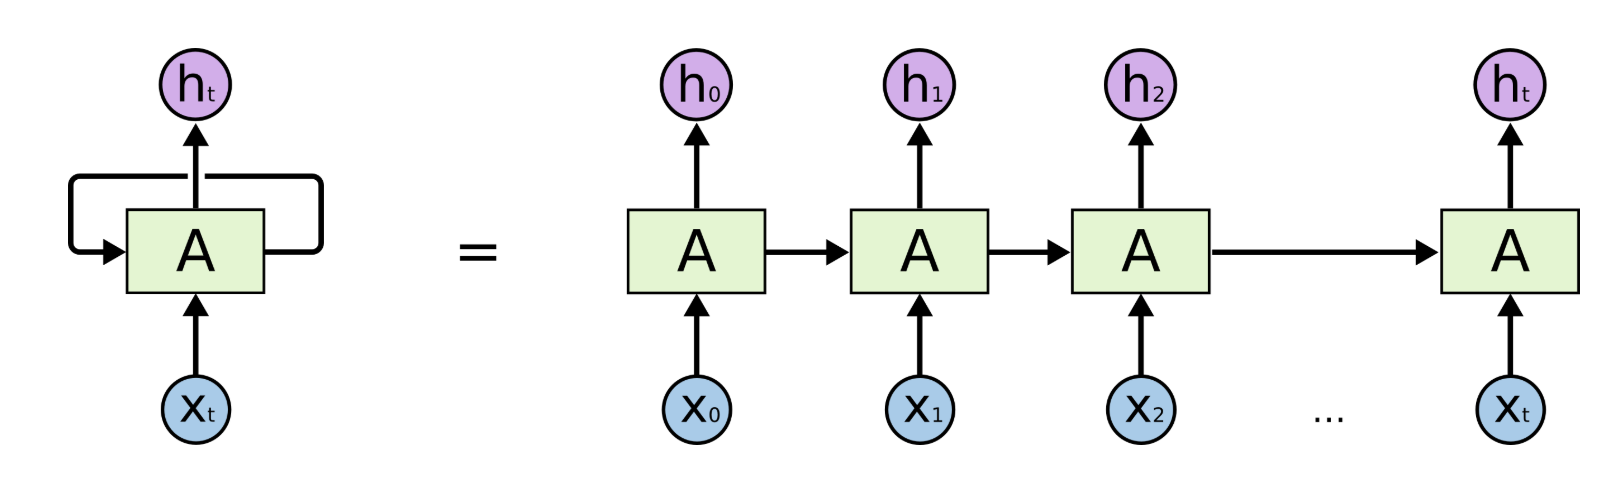

**Source:** https://colah.github.io/posts/2015-08-Understanding-LSTMs/

### Key idea
Maintain a **hidden state** $h_t$ that summarizes the past. Each step updates the state and predicts the next token. Here $A$ is a neural network which is trained as **each** token $X_i$ that passes through it in a sequence.  The important thing to remeber is that there is only one neural network $A$ whose **weights** are changed in response to each $X_i$ it sees in a sequenece. 

### What is learned (parameters)

Assume:
- Vocabulary size: $V$ indicating the words (and eventually tokens) in a corpose (e.g., "hello", "how", "are", ...)
- Embedding dimension: $d$  representing the dimension of the word embeddings
- Hidden size: $H$ representing a state that $remembers$ the "context" of previously seen words

The learnable parameters are:

- **Embedding matrix** $E \in \mathbb{R}^{V \times d}$ 
  - Looks up a dense vector for each token.
  - **Learns semantic/syntactic token representations** (e.g., similar tokens end up with similar embeddings).

- **Input-to-hidden weights** $W_{xh} \in \mathbb{R}^{H \times d}$ 
  - Converts the current input embedding $x$ into a contribution to the new hidden state.
  - **Learns how the current token should influence memory**.

- **Hidden-to-hidden (recurrent) weights** $W_{hh} \in \mathbb{R}^{H \times H}$ 
  - Transforms the previous hidden state $h_{t-1}$ into a contribution to the new hidden state $h_{t}$.
  - **Learns how to carry and update temporal memory** (how past information persists/decays/combines).

- **Hidden bias** $b_h \in \mathbb{R}^{H}$  
  - Shifts the pre-activation for the hidden state.
  - **Learns baseline offsets** for hidden activations.

- **Hidden-to-output weights** $W_{hy} \in \mathbb{R}^{V \times H}$ 
  - Maps hidden state to logits (or output) over the vocabulary. So each $v$ in $V$ gets assigned a number (or probability). 
  - **Learns how internal features correspond to next-token predictions**.

- **Output bias** $b_y \in \mathbb{R}^{V}$  
  - Shifts logits for each token.
  - **Learns baseline token preferences** (e.g., frequency effects).

Collectively, the parameter set is:

$$
\theta = \{E, W_{xh}, W_{hh}, b_h, W_{hy}, b_y\}.
$$

### Core equations

Let the input token be $x_t \in \{1,\dots,V\}$ and the embedding lookup be:

$$
e(x_t) = E[x_t] \in \mathbb{R}^{d}.
$$

**Hidden state update:**
$$
h_t = \phi\left(W_{xh} e(x_t) + W_{hh} h_{t-1} + b_h\right),
$$
where $\phi$ is typically $\tanh$ or ReLU.

**Output logits and probabilities:**
$$
z_{t+1} = W_{hy} h_t + b_y,
\quad
p(x_{t+1}\mid x_{\le t}) = \text{softmax}(z_{t+1}).
$$

### Training stage (teacher forcing)

Given a training sequence $x_{1:T}$, minimize negative log-likelihood (cross-entropy):

$$
\mathcal{L}(\theta)
=
-\sum_{t=1}^{T} \log p_\theta(x_t \mid x_{<t}).
$$

**What happens during training:**
- At each step, the model consumes the **true** token $x_t$ (via its embedding) to compute $h_t$.
- It then predicts the distribution for the next token (or equivalently predicts $x_t$ from $h_{t-1}$ depending on indexing).
- Gradients are computed by **backpropagation through time (BPTT)**, updating:
  - $E$ to create useful token vectors,
  - $W_{xh}, W_{hh}, b_h$ to update memory,
  - $W_{hy}, b_y$ to map hidden features to next-token probabilities.

### Sampling stage (generation)

Start with a seed token (e.g., $x_1 = \langle \text{BOS} \rangle$ or a prompt) and an initial hidden state $h_0$ (often zeros).

For $t=1,2,\dots$:

1. Embed current token: $e(x_t) = E[x_t]$ 
2. Update hidden state:
   $$
   h_t = \phi\left(W_{xh} e(x_t) + W_{hh} h_{t-1} + b_h\right)
   $$
3. Compute next-token distribution:
   $$
   p(x_{t+1}\mid x_{\le t}) = \text{softmax}(W_{hy} h_t + b_y)
   $$
4. Sample:
   $$
   x_{t+1} \sim \text{Categorical}\left(p(\cdot)\right)
   $$
   (or take $\arg\max$)
5. Repeat until $\langle \text{EOS} \rangle$ or a length limit

**Key difference from training:** during sampling, the model conditions on its **own generated tokens**, not ground-truth tokens.

## A Tiny RNN Autoregressive Model on Binary Strings (0/1)

We build an autoregressive RNN that predicts the next digit in a binary sequence:
$$
x_{1:T}, \quad x_t \in \{0,1\}.
$$

We will keep **everything small**:

- Vocabulary size: $V = 2$ (tokens: 0 and 1)  
- Embedding size: $d = 2$  
- Hidden size: $H = 2$ 

### Model definition (parameters and shapes)

### Embedding matrix
We use a learnable embedding matrix:
$$
E \in \mathbb{R}^{V \times d} = \mathbb{R}^{2 \times 2}.
$$

So:
$$
e(0) = E[0] \in \mathbb{R}^{2}, \quad e(1) = E[1] \in \mathbb{R}^{2}.
$$

To keep the example concrete, assume simple embeddings:

$$
E =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix},
\quad
e(0)=
\begin{bmatrix}1\\0\end{bmatrix},
\quad
e(1)=
\begin{bmatrix}0\\1\end{bmatrix}.
$$

### RNN parameters
Hidden update:
$$
h_t = \tanh(W_{xh} e(x_t) + W_{hh} h_{t-1} + b_h)
$$

with:
- $$W_{xh} \in \mathbb{R}^{H \times d} = \mathbb{R}^{2 \times 2}$$
- $$W_{hh} \in \mathbb{R}^{H \times H} = \mathbb{R}^{2 \times 2}$$
- $$b_h \in \mathbb{R}^{H} = \mathbb{R}^{2}$$

Output logits:
$$
z_{t+1} = W_{hy} h_t + b_y
$$

with:
- $$W_{hy} \in \mathbb{R}^{V \times H} = \mathbb{R}^{2 \times 2}$$
- $$b_y \in \mathbb{R}^{V} = \mathbb{R}^{2}$$

Next-token probabilities:
$$
p(x_{t+1}\mid x_{\le t}) = \text{softmax}(z_{t+1}).
$$

### Training setup (teacher forcing)

Given a training sequence, e.g.
$$
x_{1:6} = [0,1,0,1,0,1],
$$
we train the model to predict:
$$
x_2 \text{ from } x_1,\;
x_3 \text{ from } x_2,\;
\dots,\;
x_6 \text{ from } x_5.
$$

Objective:
$$
\mathcal{L}(\theta) = -\sum_{t=1}^{T-1} \log p_\theta(x_{t+1} \mid x_{\le t}).
$$

Teacher forcing means: when predicting $x_{t+1}$, we feed the **true** $x_t$ to compute $h_t$.

### One full forward pass (concrete numbers)

We choose specific small weights to show the mechanics.

### Choose weights
Let:

$$
W_{xh} =
\begin{bmatrix}
1 & 0 \\
0 & 1
\end{bmatrix},
\quad
W_{hh} =
\begin{bmatrix}
0 & 0 \\
0 & 0
\end{bmatrix},
\quad
b_h =
\begin{bmatrix}
0\\0
\end{bmatrix}.
$$

So the hidden state depends only on the current input embedding:
$$
h_t = \tanh(e(x_t)).
$$

Let the output layer be:

$$
W_{hy} =
\begin{bmatrix}
\;\;1 & -1 \\
-1 & \;\;1
\end{bmatrix},
\quad
b_y =
\begin{bmatrix}
0\\0
\end{bmatrix}.
$$

Interpretation:
- If $h_t$ is more like $[1,0]^\top$, prefer output token 0.
- If $h_t$ is more like $[0,1]^\top$, prefer output token 1.

### Initialize
Set:
$$
h_0 =
\begin{bmatrix}
0\\0
\end{bmatrix}.
$$

### Step t=1 (input x₁ = 0, predict x₂)

Embedding:
$$
e(x_1) = e(0)=
\begin{bmatrix}1\\0\end{bmatrix}.
$$

Hidden:
$$
h_1 = \tanh(e(0)) =
\begin{bmatrix}\tanh(1)\\ \tanh(0)\end{bmatrix}
\approx
\begin{bmatrix}0.761\\0\end{bmatrix}.
$$

Logits for next token:
$$
z_2 = W_{hy} h_1 =
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}
\begin{bmatrix}0.761\\0\end{bmatrix}
=
\begin{bmatrix}0.761\\-0.761\end{bmatrix}.
$$

Probabilities:
$$
p(x_2 \mid x_1) = \text{softmax}(z_2).
$$

Since $0.761 > -0.761$, the model assigns higher probability to token **0**.

### Step t=2 (input x₂ = 1, predict x₃)

Embedding:
$$
e(x_2) = e(1)=
\begin{bmatrix}0\\1\end{bmatrix}.
$$

Hidden:
$$
h_2 = \tanh(e(1)) =
\begin{bmatrix}\tanh(0)\\ \tanh(1)\end{bmatrix}
\approx
\begin{bmatrix}0\\0.761\end{bmatrix}.
$$

Logits:
$$
z_3 = W_{hy} h_2 =
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}
\begin{bmatrix}0\\0.761\end{bmatrix}
=
\begin{bmatrix}-0.761\\0.761\end{bmatrix}.
$$

Now token **1** has higher probability.

### What does this show?

- The RNN processes tokens **sequentially**.
- Each step produces a **distribution** for the next token.
- In a real trained RNN, $W_{hh}$ would be nonzero and learn how to store history (not just the current token).
- Training would adjust $E, W_{xh}, W_{hh}, W_{hy}$ so the next-token predictions match the dataset pattern (e.g., alternating 0/1).

### Sampling stage (generation)

Given a start token $x_1$:

1. Compute $h_1$, then $p(x_2\mid x_1)$  
2. Sample $x_2$ 
3. Feed $x_2$ back in, compute $h_2$, then $p(x_3\mid x_{1:2})$  
4. Repeat to generate a full binary sequence

## Long Short-Term Memory (LSTM) 

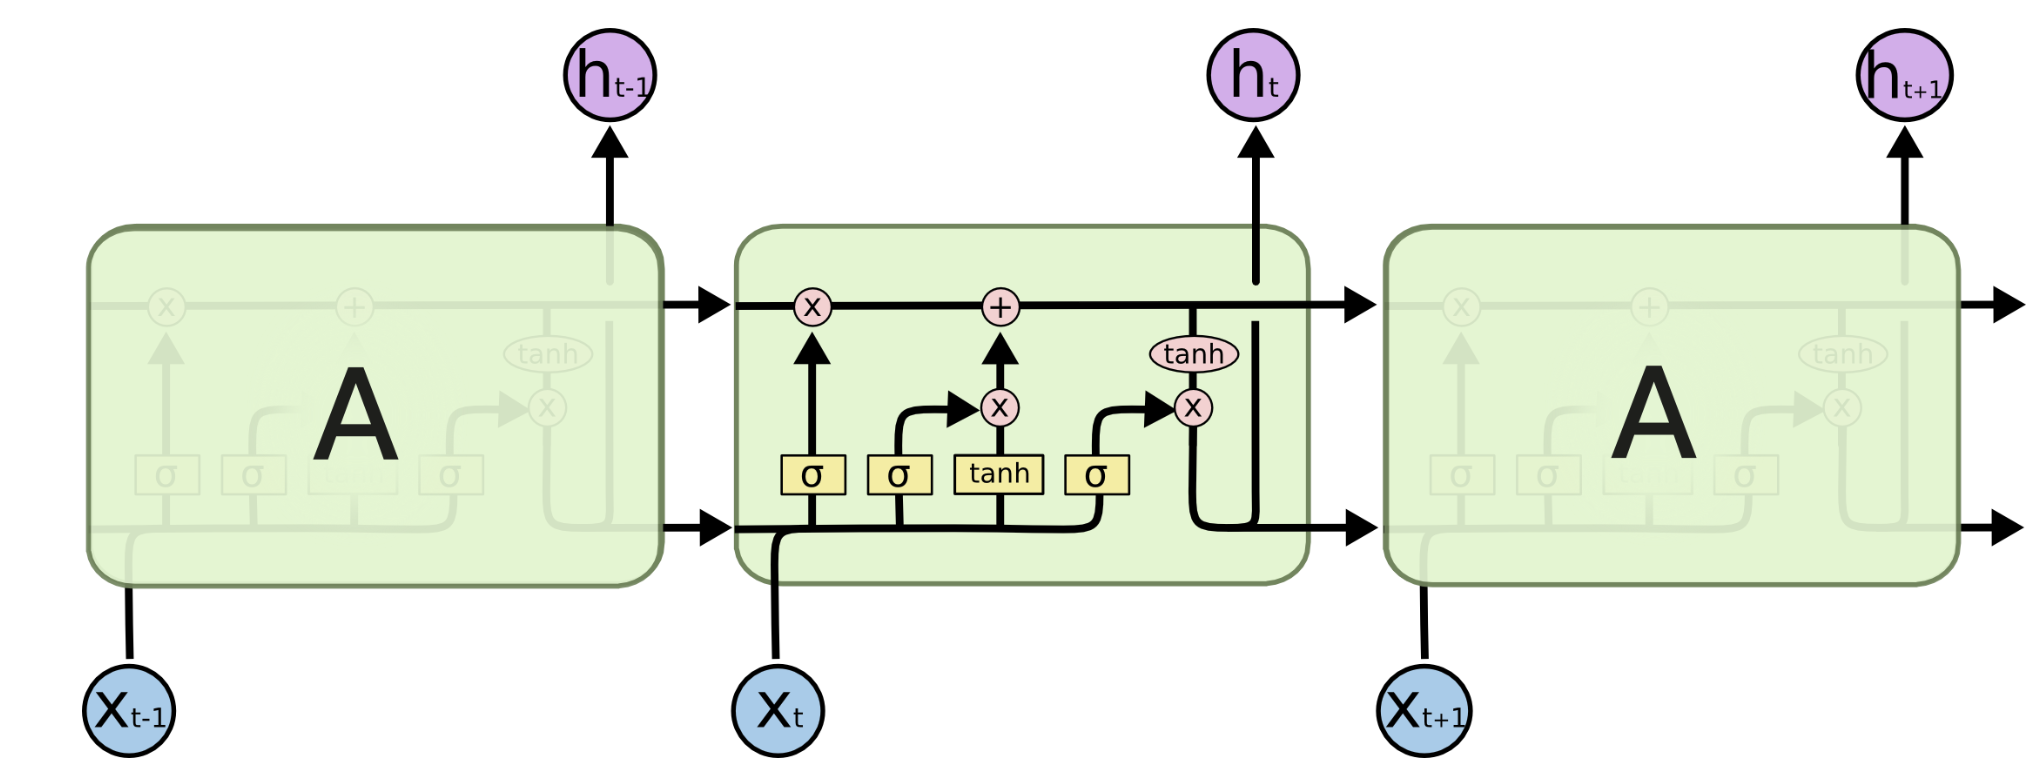
**Source:** https://colah.github.io/posts/2015-08-Understanding-LSTMs/

An **LSTM (Long Short-Term Memory)** is a recurrent model designed to fix a core weakness of vanilla RNNs:  
**it is hard for gradients and information to survive across many time steps.**

The LSTM introduces a dedicated **memory cell** $c_t$ and **gates** that learn when to:

- **forget** old information
- **write** new information
- **expose** (read out) information to make predictions

The key intuition is that the cell state $c_t$ (top $arrow$ in the diagram above) can behave like a **nearly linear “information highway”** through time, while the gates learn *how much* to modify it.

#### What is learned (parameters and what each learns)

Assume:
- input embedding dimension: $d$
- hidden size: $H$

Inputs:
- $x_t \in \mathbb{R}^{d}$ (embedding of token $x_t$)
- $h_{t-1} \in \mathbb{R}^{H}$ (previous hidden state)
- $c_{t-1} \in \mathbb{R}^{H}$ (previous cell/memory)

The dimensions of $h_{t-1}$ and $c_{t-1}$ are typically the same. 

#### Gate parameters (learned)
Each gate is a sigmoid unit:
$$
\sigma(\cdot) \in (0,1),
$$
so it outputs a **soft on/off** control for each hidden dimension.

We have three gates and one candidate update:

- **Input gate** parameters:
  - $W_i \in \mathbb{R}^{H \times d}$ (how current input proposes writing)
  - $U_i \in \mathbb{R}^{H \times H}$ (how past hidden proposes writing)
  - $b_i \in \mathbb{R}^{H}$ (baseline write tendency)

  **What it learns:** *when and how strongly to write new information into memory.*

- **Forget gate** parameters:
  - $W_f \in \mathbb{R}^{H \times d}$
  - $U_f \in \mathbb{R}^{H \times H}$
  - $b_f \in \mathbb{R}^{H}$

  **What it learns:** *when to erase/keep each memory component.*

- **Output gate** parameters:
  - $W_o \in \mathbb{R}^{H \times d}$
  - $U_o \in \mathbb{R}^{H \times H}$
  - $b_o \in \mathbb{R}^{H}$

  **What it learns:** *what part of the memory should be exposed to the model’s output/decision.*

- **Candidate memory (write proposal) parameters:**
  - $W_c \in \mathbb{R}^{H \times d}$
  - $U_c \in \mathbb{R}^{H \times H}$
  - $b_c \in \mathbb{R}^{H}$

  **What it learns:** *what new content should be written into memory (before gating).*

#### Output (language model) parameters (learned)
If we use the LSTM for next-token prediction over a vocabulary of size $V$:

- $W_{hy} \in \mathbb{R}^{V \times H}$ (map hidden features to token logits)
- $b_y \in \mathbb{R}^{V}$

**What it learns:** *how hidden features correspond to next-token probabilities.*

So the total learnable parameters are:
$$
\theta = \{W_i,U_i,b_i,\; W_f,U_f,b_f,\; W_o,U_o,b_o,\; W_c,U_c,b_c,\; W_{hy},b_y\}.
$$

### LSTM equations

#### Gates (sigmoid in $[0,1]$)

**Input gate**
$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

**Forget gate**
$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

**Output gate**
$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

#### Candidate memory content (tanh in $[-1,1]$)
$$
\tilde{c}_t = \tanh(W_c x_t + U_c h_{t-1} + b_c)
$$

#### Cell (memory) update
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

Interpretation:
- $f_t \odot c_{t-1}$ = **keep/forget** old memory
- $i_t \odot \tilde{c}_t$ = **write** new memory

#### Hidden state (readout from memory)
$$
h_t = o_t \odot \tanh(c_t)
$$

Interpretation:
- $\tanh(c_t)$ squashes memory to a bounded range
- $o_t$ chooses **what to expose** from memory at this time

#### The intuition in one picture (conceptual)

Think of the cell update:

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

as a learned **soft overwrite rule**:

- If $f_t \approx 1$ and $i_t \approx 0$, then $c_t \approx c_{t-1}$  
  → memory is **copied forward** almost unchanged (long-term storage).

- If $f_t \approx 0$ and $i_t \approx 1$, then $c_t \approx \tilde{c}_t$  
  → memory is **overwritten** with new content.

- If both are in between, LSTM performs a **learned interpolation**.

This is the mechanism that lets LSTMs keep important information for long spans and update it only when needed.

### Training stage (teacher forcing for next-token prediction)

For a token sequence $x_{1:T}$, we compute hidden states sequentially:

$$
(h_t,c_t) = \text{LSTM}(x_t, h_{t-1}, c_{t-1}),
$$

then predict the next token with:

$$
z_{t+1} = W_{hy} h_t + b_y,
\quad
p(x_{t+1}\mid x_{\le t}) = \text{softmax}(z_{t+1}).
$$

Loss (negative log-likelihood):

$$
\mathcal{L}(\theta) = -\sum_{t=1}^{T-1} \log p_\theta(x_{t+1}\mid x_{\le t}).
$$

**Teacher forcing:** at step $t$, you feed the **true** $x_t$ from the dataset (not the model’s sampled output).

Gradients are computed by **backpropagation through time (BPTT)**, updating all gate and output parameters.

### Sampling stage (generation)

Initialize $h_0,c_0$ (often zeros), and start from a prompt (or a special token).

For $t=1,2,\dots$:

1. Compute gates $i_t,f_t,o_t$ and candidate $\tilde{c}_t$ from $x_t,h_{t-1}$  
2. Update memory $c_t$ and hidden state $h_t$
3. Compute next-token distribution:
   $$
   p(x_{t+1}\mid x_{\le t}) = \text{softmax}(W_{hy} h_t + b_y)
   $$
4. Sample:
   $$
   x_{t+1} \sim \text{Categorical}(p(\cdot))
   $$
5. Feed the sampled token back in and repeat

**Key difference from training:** during sampling, the model conditions on its **own outputs**, which can cause error accumulation (exposure bias).

### Summary

The LSTM learns **when to remember, when to forget, and when to reveal memory** via gates:

- $f_t$ = keep/forget old memory
- $i_t$ = write new memory
- $o_t$ = expose memory to prediction

All of this is learned through next-token prediction loss and BPTT.

### Conceptually: what do the $U$ matrices do in LSTMs?

In an LSTM, every gate is influenced by **two things**:
1. the current input $x_t$ (via $W_*$)
2. the previous hidden state $h_{t-1}$ (via $U*$)

So, **the $U$ matrices are the “recurrent/context” weights**: they decide how the model’s *current context* (stored in $h_{t-1}$) should affect each gate’s decision.

#### Input gate: $U_i$ — “should we write new info?”

Input gate:
$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i).
$$

- **Role of $U_i$:** uses the context $h_{t-1}$ to control **how much new information** gets written into memory.
- Intuition: “Given what I already know, do I need to update memory now?”

#### Forget gate: $U_f$ — “should we keep or erase memory?”

Forget gate:
$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f).
$$

- **Role of $U_f$:** uses the context $h_{t-1}$ to decide **what to retain** from the previous cell state $c_{t-1}$.
- Intuition: “Given what I’ve been tracking, is the old memory still relevant or should I drop it?”

#### Output gate: $U_o$ — “what part of memory should I reveal?”

Output gate:
$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o).
$$

- **Role of $U_o$:** uses the context $h_{t-1}$ to decide **how much of the cell state** should be exposed as the hidden state output $h_t$.
- Intuition: “Given the current context, how much should I show to the outside world right now?”

## Summary

The $U$ matrices make the gates **context-aware**: they tell each gate how to use the previous hidden state $h_{t-1}$ to decide **write** ($U_i$), **keep/erase** ($U_f$), and **reveal** ($U_o$).

## Backpropagation Through Time (BPTT)

For an RNN/LSTM, the hidden state is computed **sequentially**:

$$
h_t = f_\theta(h_{t-1}, x_t),
\quad t=1,\dots,T.
$$

For next-token prediction, a common loss is:

$$
\mathcal{L}(\theta) = \sum_{t=1}^{T-1} \ell_t(\theta),
\quad
\ell_t(\theta) = -\log p_\theta(x_{t+1}\mid x_{\le t}).
$$

**Backpropagation Through Time (BPTT)** means we compute gradients of the total loss with respect to parameters by applying the chain rule **through the unrolled time steps**:

$$
\frac{\partial \mathcal{L}}{\partial \theta}
=
\sum_{t=1}^{T-1} \frac{\partial \ell_t}{\partial \theta}.
$$

Because each $h_t$ depends on earlier states, each term includes indirect dependencies via the recurrence. A useful way to see this is:

$$
\frac{\partial \ell_t}{\partial \theta}
=
\sum_{k=1}^{t}
\frac{\partial \ell_t}{\partial h_t}
\frac{\partial h_t}{\partial h_{t-1}}
\cdots
\frac{\partial h_{k}}{\partial \theta}.
$$

So gradients propagate backward along time:

$$
\ell_t \rightarrow h_t \rightarrow h_{t-1} \rightarrow \cdots \rightarrow h_1.
$$

### Practical notes
- BPTT can suffer from **vanishing/exploding gradients** when $$\left\|\frac{\partial h_t}{\partial h_{t-1}}\right\|$$ repeatedly shrinks or grows across many steps.
- Common stabilizers: **gradient clipping**, gated units (LSTM/GRU), and **truncated BPTT** (backprop only across a fixed window of time steps).

## What is a Transformer?

A Transformer primary role (at least in its internal layers) is to compute a **contextualized representation** for every token position.

Start with a token sequence:

$
x_1, x_2, \dots, x_T
$

After embedding (token + position), we have initial vectors:

$
h_1^{(0)}, h_2^{(0)}, \dots, h_T^{(0)}.
$

A Transformer applies multiple layers. Each layer updates every token’s vector by mixing in information from other tokens (via **attention**):

$
h_t^{(\ell+1)} = \mathrm{Block}\left(h_1^{(\ell)},\dots,h_T^{(\ell)}\right)_t.
$

So after $L$ layers, each token has a final contextual vector:

$
h_t^{(L)} \in \mathbb{R}^{d}.
$

### What does “contextual” mean here?
It means $h_t^{(L)}$ is not just “the embedding of token $t$”, but a representation that depends on the entire sentence:

$
h_t^{(L)} = f_\theta(x_1, x_2, \dots, x_T; t).
$

For example, the vector for “bank” will be different in:

- ${\color{red}*}$ “river bank”
- ${\color{blue}*}$“bank account”

because attention allows the token “bank” to incorporate information from nearby words (“river” vs “account”).

### Autoregressive (GPT-style) vs bidirectional (BERT-style)
- **GPT / decoder-only:** token $t$ can only attend to $j \le t$ (past context).
- **BERT / encoder:** token $t$ can attend to all $j \in \{1,\dots,T\}$ (full context).

### Summary
A Transformer repeatedly applies attention + MLP updates so that every token’s vector becomes a **context-dependent (“contextual”) meaning representation** that is useful for the final task (next-token prediction, classification, etc.).

## Transformers: Architecture

Transformers became the dominant sequence modeling architecture because they address two core bottlenecks of LSTMs:

1. **Sequential computation** (slow training/inference for long sequences)
2. **Long-range dependency learning** (hard credit assignment across many steps)

The Transformer replaces **recurrence** with **self-attention**, enabling strong performance and **excellent scaling** with data/compute.

### LSTM bottlenecks

#### Inherently sequential training
An LSTM computes states step-by-step:

$$
(h_t, c_t) = \mathrm{LSTM}(x_t, h_{t-1}, c_{t-1}),
\quad t=1,\dots,T.
$$

You cannot compute $h_t$ until you have $h_{t-1}$, so training has limited parallelism over time.

#### Long-range dependencies have long gradient paths
Even with gates, the influence of $x_1$ on the loss at time $t$ must flow through many intermediate states:

$$
x_1 \rightarrow (h_1,c_1) \rightarrow (h_2,c_2) \rightarrow \cdots \rightarrow (h_t,c_t) \rightarrow \ell_t.
$$

This creates a long credit-assignment chain (still challenging at scale).

### Key Transformer ideas

#### Key idea #1: Self-attention instead of recurrence

At a layer, each position can directly mix information from other positions.

Given hidden states $X \in \mathbb{R}^{T \times d}$:

$$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V,
$$

Scaled dot-product attention:

$$
A = \mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right),
\quad
\mathrm{Att}(X) = AV.
$$

- In **autoregressive** Transformers (GPT-style), $M$ is a **causal mask**:
  $$
  M_{t,u} =
  \begin{cases}
  0, & u \le t\\
  -\infty, & u > t
  \end{cases}.
  $$

**This is important because:** token $t$ can attend directly to token $t-200$ in one hop.

#### Key idea #2: Multi-head attention 

Instead of one attention, use $H$ heads (similar to multiple filters in CNNs):

$$
\mathrm{head}_h = \mathrm{Att}(XW_Q^{(h)}, XW_K^{(h)}, XW_V^{(h)}),
$$
$$
\mathrm{MHA}(X) = \mathrm{Concat}(\mathrm{head}_1,\dots,\mathrm{head}_H)W_O.
$$

**This is important because:** different heads specialize (syntax, coreference, local patterns, global topics, etc.).

#### Key idea #3: Parallel training over sequence positions
With causal masking (or bidirectional masking for encoders), Transformers compute all positions in parallel in a forward pass:

$$
X^{(l+1)} = \mathrm{Block}(X^{(l)}),
$$

rather than step-by-step recurrence. This maps extremely well to GPUs/TPUs.

**This is important because::** training scales efficiently to huge datasets and models.

#### Key idea #4: Positional information is explicit
Because attention is permutation-invariant, Transformers add **positional information**:

- Learned positional embeddings:
  $$
  x_t^{(0)} = W_e[s_t] + W_p[t].
  $$
- Or sinusoidal positional encodings (original Transformer).

**This is important because::** the model learns order **without recurrence**.

#### Key idea #5: Residual connections + LayerNorm stabilize deep networks
A typical pre-LN block:

$$
X' = X + \mathrm{MHA}(\mathrm{LN}(X)),
$$
$$
X^{\text{next}} = X' + \mathrm{FFN}(\mathrm{LN}(X')).
$$

**This is important because::** enables much deeper models and more stable optimization.

#### Key idea #6: The FFN (MLP) expands capacity per token
Per position:

$$
\mathrm{FFN}(x) = W_2\,\sigma(W_1x + b_1) + b_2,
$$

commonly with **GELU**. This gives a powerful nonlinearity at each token position.

### Why Transformers are better in practice

#### Better long-range modeling
Self-attention creates short paths:

- LSTM path length from token $i$ to token $t$ is $O(t-i)$
- Transformer path length (within a layer) is $O(1)$ because attention can connect any pair directly

This often improves tasks needing long context (documents, code, dialogue, retrieval-like behavior).

#### Faster training due to parallelism
Even though self-attention is $O(T^2)$ in sequence length, it is highly parallel and typically faster than sequential recurrence for moderate-to-long contexts.

#### Better scaling laws and transfer
Transformers scale smoothly with:
- model size
- data size
- compute

and yield strong generalization and “few-shot” style transfer when trained autoregressively on diverse data.

#### Important caveat (where LSTMs can still win)

For very long sequences with tight compute/memory:
- Standard attention costs $O(T^2)$ memory/time.
- LSTMs cost $O(T)$ and may be more efficient for certain streaming or embedded settings.

This is why efficient attention, state-space models, and hybrids exist.

#### Summary
Transformers won because **self-attention + parallel training + stable deep optimization** made it easier to learn long-range structure and scale to large datasets and models, outperforming LSTMs on most modern sequence tasks.

## Transformer: Why we need “Attention”

Consider the sentence:

> **“the pink elephant tried to get into the car but it was too …”**

When you reach the word **“too”**, you (as a human) immediately know you must look back in the sentence to decide:

- **too what?** too *big*? too *small*? too *old*?
- what is “it”? does **it** refer to the **car** or the **elephant**?
- what earlier word(s) provide the key information to interpret “too”?

### The core problem: not all past words matter equally
At the moment you process **“too”**, the most useful tokens are likely:

- **“car”** (it was too ___ to get into the car)
- **“elephant”** (an elephant is big; maybe the elephant is too big)
- **“it”** (coreference: what does “it” refer to?)

But many tokens are less important:

- “the”, “pink”, “tried”, “to”, “get”, “into”, “but”, “was”  

So we want the model to do something like:

> “When computing the representation of **too**, pay *more* attention to **car / elephant / it**, and *less* to the rest.”

### Why LSTMs/RNNs struggle here 
In an RNN/LSTM, information from earlier tokens must be compressed into a single evolving state:

$$
(h_t, c_t) = \mathrm{LSTM}(x_t, h_{t-1}, c_{t-1}).
$$

So by the time we reach “too”, the model must have **carried** the relevant facts about “car” and “elephant” through many steps. This is possible, but it is indirect and can be difficult for long sequences.

### What attention adds
**Attention** gives a direct mechanism:

> “At position $t$, look back at all earlier positions $1..t$, decide which ones are relevant, then mix their information.”

This is like having a **soft search-and-retrieve** over the sentence.

### What “self-attention” means
- **Attention** means “use a query to retrieve information from a set of (key, value) pairs.”
- **Self-attention** means the query, keys, and values all come from the **same sequence**.

So in our sentence:
- the token **“too”** creates a **query**
- every token in the sentence provides **keys** and **values**
- “too” uses its query to decide how much to use each token’s value

### What are the **keys** and **values** in self-attention?

In **self-attention**, the query, keys, and values all come from the **same sentence**.

Assume the sentence is tokenized into $T$ tokens, with embeddings:

$$
x_1, x_2, \dots, x_T, \quad x_j \in \mathbb{R}^{d_e}.
$$

#### Which token provides the **query**?
If we are computing the contextual representation for the token at position $t$ (here the word **“too”**), then:

The **query** comes from the current token’s embedding $x_t$:

$
q_t = x_t W_Q \in \mathbb{R}^{d_k}.
$

So: **“too” provides the query** (because we are asking: what context does “too” need?). **Query** is the target *token* for which we need to know the *Context* for. 

#### Which tokens provide the **keys** and **values**?
**Every token position $j$ in the sentence provides:**
- a **key** vector $k_j$
- a **value** vector $v_j$

computed from that token’s embedding $x_j$:

$$
k_j = x_j W_K \in \mathbb{R}^{d_k},
\quad
v_j = x_j W_V \in \mathbb{R}^{d_v}.
$$

So:

- The token **“car”** provides $k_{\text{car}}$ and $v_{\text{car}}$  
- The token **“elephant”** provides $k_{\text{elephant}}$ and $v_{\text{elephant}}$  
- The token **“it”** provides $k_{\text{it}}$ and $v_{\text{it}}$ 
- Even function words like **“the”** provide their own $k_j, v_j$ (usually they receive small weights)

> **Important:** A “key” is **not** “the previous token.”  
> A key is a **learned projection of each token’s embedding** that acts like an “address/label” for matching.

### **key** = “What do I contain/what am I about?”

For the current token at position $t$, we have a **query** $q_t$. The relevance score is:

$
s_{t,j} = \frac{q_t \cdot k_j}{\sqrt{d_k}}.
$

#### What is this score, intuitively?

- The dot product $q_t \cdot k_j$ is a **similarity** measure:
  - If $q_t$ and $k_j$ point in a similar direction, the dot product is **large and positive**.
  - If they are unrelated/orthogonal, the dot product is near **0**.
  - If they point in opposite directions, it can be **negative**.

So you can think of it as:

> “How well does token $j$ match what token $t$ is looking for **regardless of the context of the sentence**?”

#### Why divide by $\sqrt{d_k}$?

If the components of $q_t$ and $k_j$ are roughly random with variance around 1, then the dot product magnitude grows with dimension:

$$
q_t \cdot k_j = \sum_{r=1}^{d_k} q_{t,r} k_{j,r},
$$

so its typical scale grows like $\sqrt{d_k}$. Dividing by $\sqrt{d_k}$ keeps scores in a stable numeric range across different head dimensions:

$$
s_{t,j} = \frac{q_t \cdot k_j}{\sqrt{d_k}} \approx O(1).
$$

This prevents the softmax (done at a later stage) from saturating too early (i.e., producing extremely peaky weights) when $d_k$ is large.

### **value** = “If you attend to me, what information should you take?”

Within a layer, token $t$ forms a weighted combination of other tokens’ **value vectors**:

$
y_t = \sum_{j=1}^{T} \alpha_{t,j}\, v_j,
\quad
\alpha_{t,j} = \mathrm{softmax}\left(\frac{q_t \cdot k_j}{\sqrt{d_k}}\right).
$

This is the mechanism by which token $t$ pulls in the information it needs from other tokens, producing an updated, more contextual representation.

The value $v_j$ is the **information payload** that will be mixed into the output:

So **values are what get averaged**, keys are what get **matched**.

Softmax converts scores into weights (so we can average). The scores $s_{t,j}$ are just real numbers (can be negative, don’t sum to 1).  
Softmax converts them into **nonnegative weights that sum to 1**:

$$
\alpha_{t,j} = \frac{\exp(s_{t,j})}{\sum_{u}\exp(s_{t,u})}.
$$

This is why we can interpret $\alpha_{t,j}$ as “how much attention token $t$ gives to token $j$”.

### In the sentence example (“… it was too …”)

When computing the representation of **“too”** (position $t$):

- **Query**: $q_t$ comes from **“too”**
- **Keys/Values**: each prior word contributes $k_j, v_j$
- If “car” is most relevant, then $\alpha_{t,\text{car}}$ is large, so $v_{\text{car}}$ strongly influences the contextual output $y_t$.

Intuitively:

- The query for “too” asks: *“What earlier context helps interpret me?”*
- Keys answer: *“Match me if I’m relevant.”*
- Values provide: *“Here is the information you should incorporate if you match me.”*

### Autoregressive (GPT-style)
In GPT-style self-attention, “too” can attend only to **previous** tokens:

$$
j \le t.
$$

So in that setting:

- keys/values come from tokens at positions $1,2,\dots,t$
- future tokens $j>t$ are masked out (not “previous token only”—**all previous tokens**).

### The role of **value**

We are computing a contextual representation for the token at position $t$ (the word **“too”**) in the sentence:

> **“the pink elephant tried to get into the car but it was too …”**

At this moment, “too” needs context to decide what comes next (e.g., *too big*). The model’s job is to create a vector $y_t$ that summarizes the **most relevant earlier information** for interpreting “too”.

### What does “value” represent for each token?

Each token $j$ has an embedding $x_j \in \mathbb{R}^{d_e}$.  
Self-attention forms three projections:

$$
k_j = x_j W_K,\quad v_j = x_j W_V,\quad q_t = x_t W_Q.
$$

- The **key** $k_j$ is used for **matching** or **score** as shown earlier (to compute relevance to the query).
- The **value** $v_j$ is the *thing we actually take from token $j$* if we decide it matters.

That is why we call $v_j$ as the **information contribution of a token**:

> If token $j$ is important for token $t$, then we want token **$j$** to **contribute information** to the representation of token $t$.  
> That contribution is the vector $v_j$.

#### Why is $v_j$ a vector?

In a neural language model, each token is represented not as a single number, but as a **feature vector**. A token is not just “car” — it has many properties

Take the word **“car”** in the sentence:

> “... tried to get into the **car** but it was too ...”

To predict what comes after **“too”**, the model may need multiple kinds of information about “car”, such as:

- “car” is a **container / object with an interior**
- “car” has a notion of **size / capacity**
- “car” is related to **getting into**
- “car” is a **noun**, object of a verb, etc.

A single scalar cannot represent all these simultaneously. A vector can. So we represent token $x_j$ by a vector $v_j \in \mathbb{R}^{d_e}$ whose coordinates are different learned features.

The value vector is a learned linear transform of the token representation:

$$
v_j = x_j W_V \in \mathbb{R}^{d_v}.
$$

Each component of $v_j$ can be thought of as a learned feature, e.g.:

$$
v_j =
\begin{bmatrix}
\text{(size-related feature)}\\
\text{(container/capacity feature)}\\
\text{(noun/object feature)}\\
\vdots
\end{bmatrix}.
$$

This is not manually designed—training learns these features because they help minimize prediction loss.

### Concrete sentence-based example
When processing **“too”**, suppose the model decides the **important earlier** word is **“car”**.

- “car” might carry **information like: *a container with limited size/entry constraint*
- “elephant” might carry information like: *very large animal*

The model needs a vector representing these facts to help predict what comes after “too”.

So the **value vectors** are the learned way each word says:

> “If you attend to me, here is the **information** you should take from me.”

Importantly, $v_j$ is **not the raw word**. It is a learned vector that can encode features useful for prediction.

### Why do we mix values with a weighted sum?

We want $y_t$ to be a combination of the relevant information from the past.

So we compute:

$$
y_t = \sum_{j=1}^{t} \alpha_{t,j}\, v_j.
$$

- If “car” is very relevant, $\alpha_{t,\text{car}}$ should be large, so $v_{\text{car}}$ contributes a lot.
- If “pink” is irrelevant, $\alpha_{t,\text{pink}}$ should be small, so $v_{\text{pink}}$ contributes almost nothing.

This is exactly like taking a **weighted average** of the value vectors.

### Where do the weights come from?

We first compute raw relevance scores:

$
s_{t,j} = \frac{q_t \cdot k_j}{\sqrt{d_k}}.
$

These are just real numbers. They can be negative or positive, and they do **not** automatically sum to 1.

But to form a stable weighted mixture, we want weights that:

1. are **nonnegative** (so “importance” is not negative),
2. sum to **1** (so it behaves like a weighted average),
3. smoothly increase when a score increases.

The standard function that does exactly this is **softmax**.

### What does softmax do and why is it used?

Given the vector of scores for fixed $t$:

$
s_{t,1}, s_{t,2}, \dots, s_{t,t},
$

softmax turns them into weights:

$
\alpha_{t,j} = \frac{\exp(s_{t,j})}{\sum_{u=1}^{t} \exp(s_{t,u})}.
$

Now:

- $\alpha_{t,j} \ge 0$
- $\sum_{j=1}^{t} \alpha_{t,j} = 1$

So $\alpha_{t,j}$ can be interpreted as:

> “How much attention token $t$ pays to token $j$.”

### Small numeric example

Suppose when computing the representation of “too” (position $t$), the model produces these scores:

- token “car”: $s_{t,\text{car}} = 2.0$
- token “elephant”: $s_{t,\text{elephant}} = 1.0$
- token “pink”: $s_{t,\text{pink}} = 0.0$

Softmax gives:

$$
\alpha_{t,\text{car}} = \frac{e^{2}}{e^{2}+e^{1}+e^{0}} \approx 0.665,
$$
$$
\alpha_{t,\text{elephant}} \approx 0.245,
\quad
\alpha_{t,\text{pink}} \approx 0.090.
$$

So the output becomes:

$$
y_t \approx 0.665\, v_{\text{car}}
+ 0.245\, v_{\text{elephant}}
+ 0.090\, v_{\text{pink}}.
$$

Interpretation:
- $y_t$ is dominated by the “car” information, with some “elephant” information mixed in.
- This combined context vector $y_t$ is then used by the next layers to help predict what comes next (likely *big*).

### Summary

- **Keys** $k_j$ are used to compute match scores with the query (relevance).
- **Softmax** converts those scores into normalized, nonnegative weights.
- **Values** $v_j$ are the information vectors that are mixed (weighted averaged) to create the contextual representation:
$
y_t = \sum_{j=1}^{t} \alpha_{t,j} v_j.
$

## Transformer Architecture 

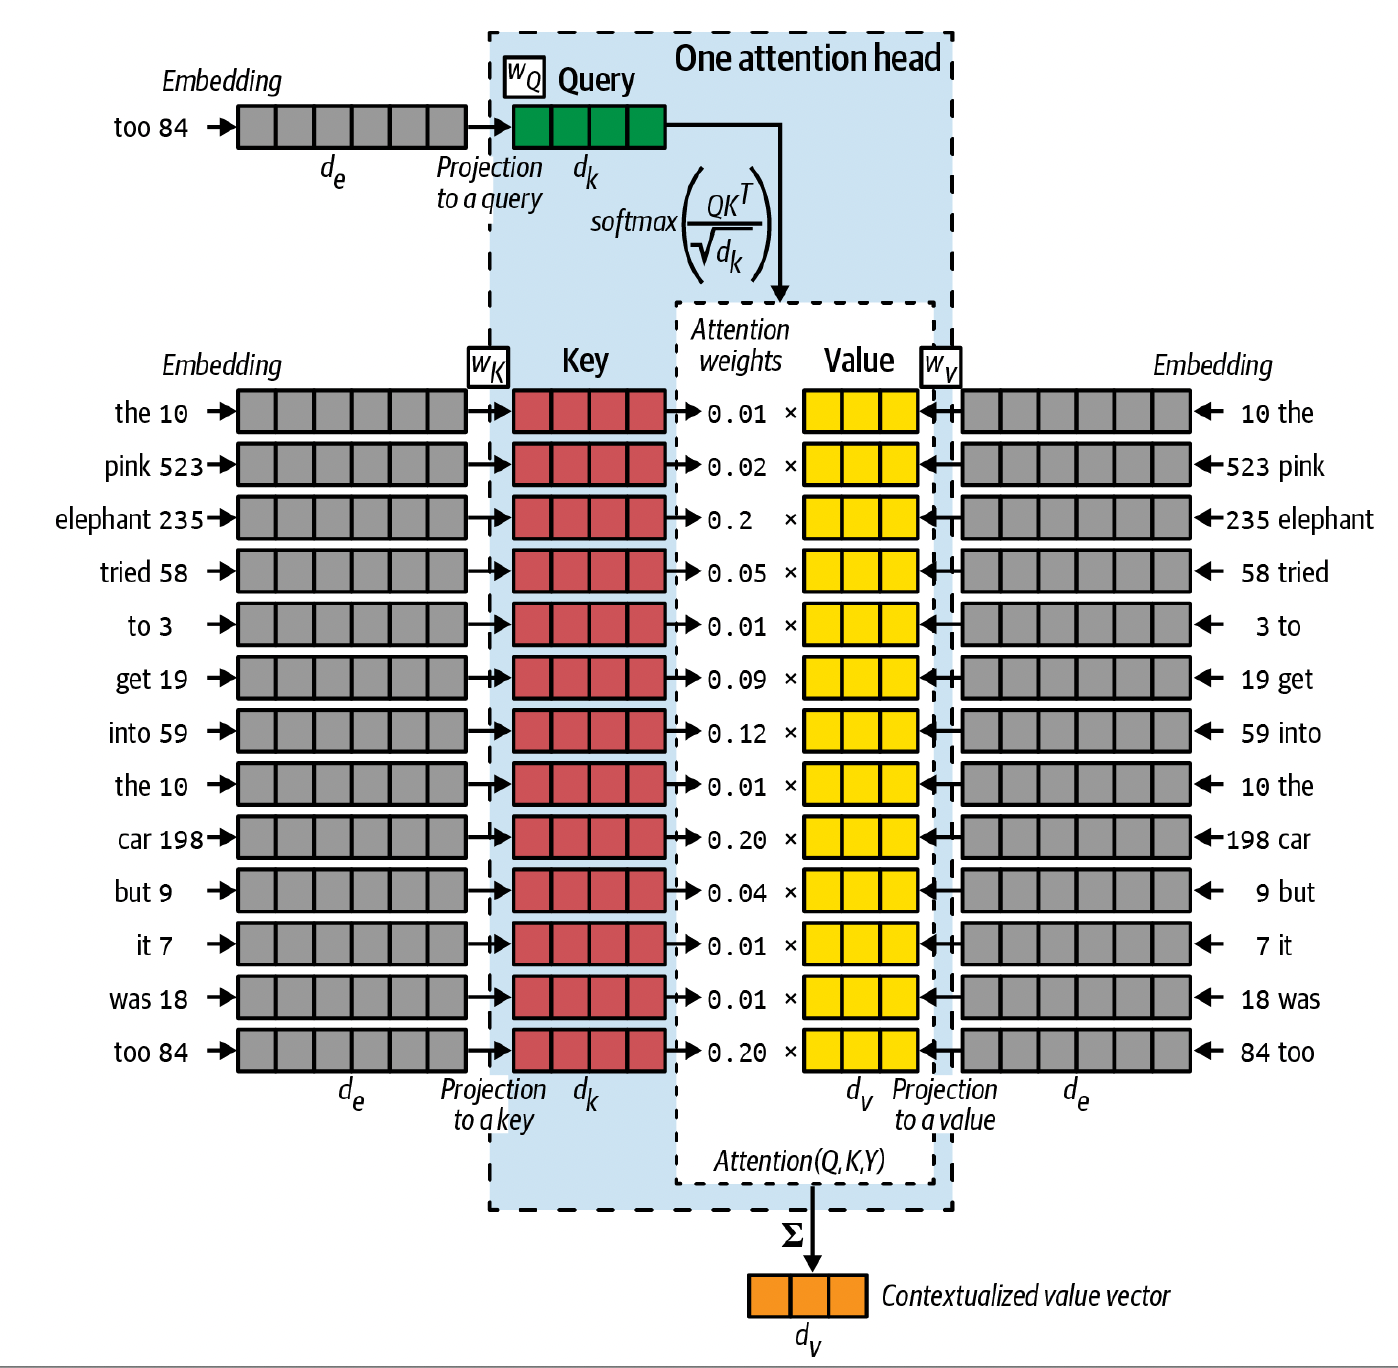

## Understanding “Attention” using the diagram (one attention head)

> **Goal:** compute a *contextualized representation* of the current token (here the last token **“too”**) by looking back at all tokens in the sequence and deciding **which ones matter most**.

### Start with token embeddings (gray blocks)

Each token in the sentence (e.g., “the”, “pink”, “elephant”, …, “too”) is mapped to an **embedding vector**:

- Embedding dimension: $d_e$ 
- Token embedding for position $j$: $x_j \in \mathbb{R}^{d_e}$

In the diagram, the gray bars are these vectors $x_j$ each representing an embedding for a token. 

### The model learns three projection matrices: $W_Q, W_K, W_V$

A single attention head learns **three** linear maps:

- $W_Q \in \mathbb{R}^{d_e \times d_k}$ (Query projection)
- $W_K \in \mathbb{R}^{d_e \times d_k}$ (Key projection)
- $W_V \in \mathbb{R}^{d_e \times d_v}$ (Value projection)

**What each learns:**
- $W_Q$ learns *what the current token is looking for* (a “search vector”).
- $W_K$ learns *how each token advertises what it contains* (an “address / label”).
- $W_V$ learns *what **information** each token will contribute if selected* (the “content payload”).

### Build Query, Keys, Values (colored blocks)

For the **current token** (here “too”), we create a **query**:

$
q = x_t W_Q \in \mathbb{R}^{d_k}.
$

For **every token** in the sequence, we create a **key** and a **value**:

$$
k_j = x_j W_K \in \mathbb{R}^{d_k}, 
\quad
v_j = x_j W_V \in \mathbb{R}^{d_v}.
$$

In the diagram:
- **Green** = query vector $q$ 
- **Red** = key vectors $k_j$  
- **Yellow** = value vectors $v_j$  

### Compute “relevance” scores with dot products

The attention head scores how relevant each token $j$ is to the current query:

$$
s_j = \frac{q \cdot k_j}{\sqrt{d_k}}.
$$

In matrix form (for a whole sequence at once for all queries and keys):

$$
S = \frac{QK^\top}{\sqrt{d_k}}.
$$

### Convert scores into **attention weights** (using softmax)

We normalize the scores across all tokens:

$
\alpha_j = \frac{\exp(s_j)}{\sum_{u=1}^{T}\exp(s_u)}.
$

So:
- $\alpha_j \ge 0$
- $\sum_{j=1}^T \alpha_j = 1$

In the diagram, these are the numbers like **0.01, 0.02, 0.20, …** next to each token.

**Interpretation:** larger $\alpha_j$ means the model considers token $j$ more relevant for understanding “too”.

### Compute the contextualized output as a weighted sum of Values

Finally, the head produces an output vector (the orange block at the bottom):

$$
y = \sum_{j=1}^{T} \alpha_j v_j \in \mathbb{R}^{d_v}.
$$

In matrix form:

$$
A = \mathrm{softmax}(S),\quad
Y = AV.
$$

Stack all value vectors as rows of a matrix:

$$
V =
\begin{bmatrix}
v_1^\top \\
v_2^\top \\
\vdots \\
v_T^\top
\end{bmatrix}
\in \mathbb{R}^{T \times d_v}.
$$

The score matrix representing score for each token against the other:

$
S \in \mathbb{R}^{T \times T}.
$

Apply softmax **row-wise** to get the attention weight matrix:

$$
A = \mathrm{softmax}(S),
\quad
A \in \mathbb{R}^{T \times T}.
$$

Row $t$ of $A$ is the distribution over tokens that token $t$ attends to:
  $$
  A_{t,:} = (\alpha_{t,1},\dots,\alpha_{t,T}).
  $$

Then the outputs for **all positions** are:

$
Y = AV \in \mathbb{R}^{T \times d_v}.
$

- If $A_{t,j}$ is large, token $j$ has a strong influence on token $t$’s updated representation.
- If $A_{t,j}$ is near 0, token $j$ contributes almost nothing to token $t$.

**Key intuition:**  
- **Keys** decide *where* to look (matching)  
- **Values** decide *what* you get from each location (content)

### (If autoregressive / GPT-style) causal masking

In a GPT-like model generating left-to-right, the token at position $t$ must not look at future tokens $> t$. We enforce:

$$
s_j =
\begin{cases}
\frac{q\cdot k_j}{\sqrt{d_k}}, & j \le t \\
-\infty, & j > t
\end{cases}
\quad\Rightarrow\quad
\alpha_j = \mathrm{softmax}(s)_j.
$$

So “too” only attends to words that came before it.

### Multi-head attention (big picture)

A real Transformer uses multiple heads. Each head has its own projections:

$$
W_Q^{(h)}, W_K^{(h)}, W_V^{(h)} \quad \text{for } h=1,\dots,H.
$$

Each head outputs $$y^{(h)}$$, then:

$$
\mathrm{MHA}(X) = \mathrm{Concat}(y^{(1)},\dots,y^{(H)})W_O.
$$

Different heads can specialize in different relations (coreference, modifiers, syntax, long-range links, etc.).

### One-sentence takeaway

**Self-attention lets the token “too” directly look back at the entire sentence, assign importance weights to earlier tokens (like “car”, “elephant”, “it”), and combine their information into a single contextualized vector.**

## **Multihead Attention**

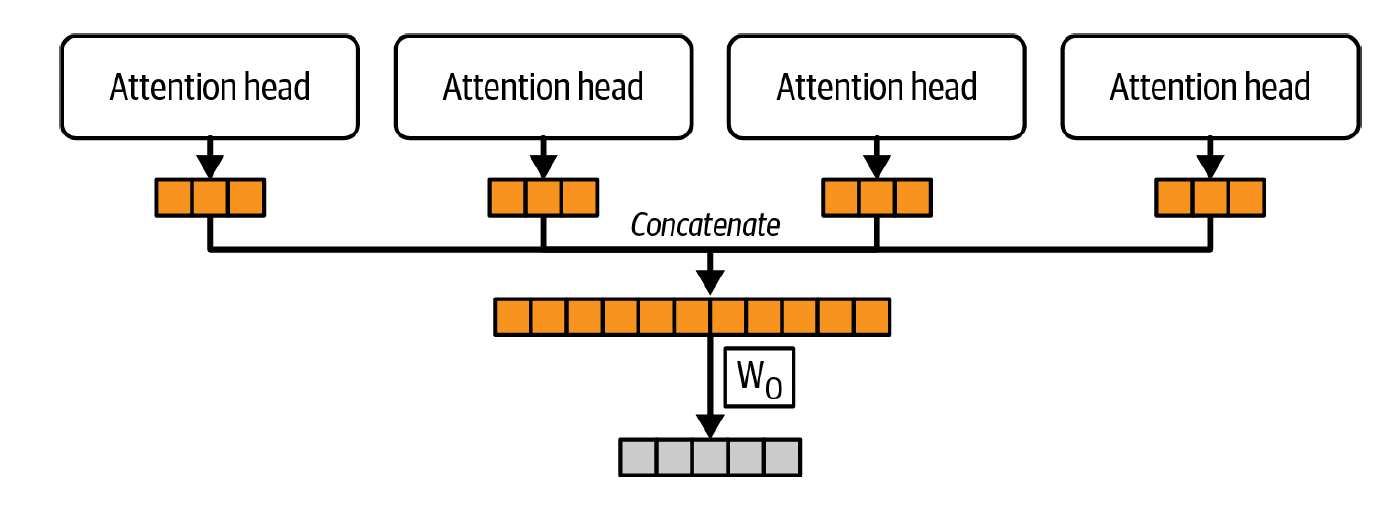

**Source**: 

Multi-head attention lets the model attend to the sequence in **multiple different ways at the same time**. Each head has its own learned projections, so different heads can specialize in different relations (e.g., local syntax, long-range coreference, etc.).

### Setup and shapes

Let the input to attention be:

$
X \in \mathbb{R}^{T \times d},
$

where:
- $T$ = sequence length
- $d$ = model dimension

Choose number of heads $H$, and per-head dimensions:

$
d_k = d_v = \frac{d}{H}.
$

(So concatenating all heads returns to dimension $d$.)

### One head (head $h$)

Each head has its own projection matrices:

$$
W_Q^{(h)} \in \mathbb{R}^{d \times d_k},\quad
W_K^{(h)} \in \mathbb{R}^{d \times d_k},\quad
W_V^{(h)} \in \mathbb{R}^{d \times d_v}.
$$

Compute:

$$
Q^{(h)} = XW_Q^{(h)},\quad
K^{(h)} = XW_K^{(h)},\quad
V^{(h)} = XW_V^{(h)}.
$$

Scores:

$$
S^{(h)} = \frac{Q^{(h)}(K^{(h)})^\top}{\sqrt{d_k}}
\in \mathbb{R}^{T \times T}.
$$

(For autoregressive / GPT-style attention, add a causal mask $M$ before softmax.)

Attention weights:

$
A^{(h)} = \mathrm{softmax}(S^{(h)} + M)
\in \mathbb{R}^{T \times T},
\quad
A^{(h)}_{t,:} = \mathrm{softmax}\big((S^{(h)}+M)_{t,:}\big).
$

Head output:

$
Y^{(h)} = A^{(h)}V^{(h)} \in \mathbb{R}^{T \times d_v}.
$

### Combine heads (concatenate + output projection)

Concatenate all heads along the feature dimension:

$$
Y_{\text{cat}} = \mathrm{Concat}(Y^{(1)},\dots,Y^{(H)})
\in \mathbb{R}^{T \times (H d_v)}.
$$

Since $H d_v = d$, this is typically:

$
Y_{\text{cat}} \in \mathbb{R}^{T \times d}.
$

Then apply a final learned output projection:

$$
W_O \in \mathbb{R}^{d \times d},
\quad
\mathrm{MHA}(X) = Y_{\text{cat}} W_O \in \mathbb{R}^{T \times d}.
$$

### Compact formula for multi-head attention

$$
\mathrm{MHA}(X) =
\mathrm{Concat}\Big(
\mathrm{Att}(XW_Q^{(1)}, XW_K^{(1)}, XW_V^{(1)}),
\dots,
\mathrm{Att}(XW_Q^{(H)}, XW_K^{(H)}, XW_V^{(H)})
\Big)W_O,
$$

where:

$$
\mathrm{Att}(Q,K,V) =
\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V.
$$

## Why multiple heads help

- A single attention head produces one set of weights per token: it can focus on only one “pattern” at a time.
- Multiple heads allow the model to compute **multiple different attention patterns in parallel**.
- After concatenation, the model keeps all these perspectives and can combine them with $W_O$.

### Summary

Multi-head attention runs several attention mechanisms in parallel, each with its own learned projections, then concatenates their outputs to produce a richer contextual representation.

## Example: A 3-token walk-through of **self-attention**

From the earlier sentence (and picture), we consider only **three tokens**:

1. **elephant**
2. **car**
3. **too**  (this is the token whose context we want to compute)

In the picture:
- **Query** (green) comes from the current token (“too”)
- **Keys** (red) come from *every token* in the sequence
- **Values** (yellow) come from *every token* in the sequence
- **Softmax weights** are the attention weights shown next to tokens
- The output is the **weighted sum of value vectors** (orange)

### Step 0 — Embeddings (gray blocks)

Let the embedding dimension be $d_e=2$ (tiny for hand calculation).

We choose simple embeddings (rows correspond to tokens, columns are embeddings):

$$
X
=
\begin{bmatrix}
x_1^\top\\
x_2^\top\\
x_3^\top
\end{bmatrix}
=
\begin{bmatrix}
1 & 0\\
0 & 1\\
0 & 1
\end{bmatrix}
\quad
\text{where }
x_1=\text{elephant},\; x_2=\text{car},\; x_3=\text{too}.
$$

> (In a real Transformer, $X$ would be token embeddings **plus** positional embeddings, but we keep it simple here.)


### Step 1 — Project to Queries / Keys / Values (green/red/yellow in the picture)

A single attention head learns three matrices:

$$
W_Q \in \mathbb{R}^{d_e \times d_k},\quad
W_K \in \mathbb{R}^{d_e \times d_k},\quad
W_V \in \mathbb{R}^{d_e \times d_v}.
$$

For this tiny example, set $d_k=d_v=2$ and use the identity projections (to keep arithmetic simple):

$
W_Q=W_K=W_V=I_2.
$

So:

$
Q=XW_Q=X,\quad K=XW_K=X,\quad V=XW_V=X.
$

### Step 2 — Compute similarity scores (the $QK^\top/\sqrt{d_k}$ box in the picture)

Scaled dot-product score matrix:

$$
S = \frac{QK^\top}{\sqrt{d_k}},
\quad d_k=2,\quad \sqrt{d_k}=\sqrt{2}.
$$

First compute $QK^\top = XX^\top$:

$$
XX^\top
=
\begin{bmatrix}
1 & 0 & 0\\
0 & 1 & 1\\
0 & 1 & 1
\end{bmatrix}.
$$

Now scale by $\sqrt{2}$:

$$
S
=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1 & 0 & 0\\
0 & 1 & 1\\
0 & 1 & 1
\end{bmatrix}
=
\begin{bmatrix}
0.707 & 0     & 0\\
0     & 0.707 & 0.707\\
0     & 0.707 & 0.707
\end{bmatrix}.
$$

Interpretation:
- Row $t$ = scores produced by **query** $q_t$ against all **keys** $k_j$.
- For token 3 (“too”), row 3 shows it matches tokens 2 and 3 more than token 1.

### Step 3 — (Autoregressive) causal mask (GPT-style)

If we are generating left-to-right, token $t$ can only attend to positions $j \le t$.

Mask entries above the diagonal to $-\infty$:

$$
S_{\text{masked}}
=
\begin{bmatrix}
0.707 & -\infty & -\infty\\
0     & 0.707   & -\infty\\
0     & 0.707   & 0.707
\end{bmatrix}.
$$

### Step 4 — Softmax to get attention weights (the numbers next to tokens in the picture)

Row-wise softmax:

$
A = \mathrm{softmax}(S_{\text{masked}}).
$

Compute each row:

- Row 1: softmax over $[0.707]$ gives
  $$
  A_{1,:} = [1,\;0,\;0].
  $$

- Row 2: softmax over $[0,\;0.707]$
  $$
  e^0=1,\quad e^{0.707}\approx 2.028,\quad \text{sum}\approx 3.028
  $$
  $$
  A_{2,:}\approx [0.330,\;0.670,\;0].
  $$

- Row 3: softmax over $[0,\;0.707,\;0.707]$
  $$
  [1,\;2.028,\;2.028],\quad \text{sum}\approx 5.056
  $$
  $$
  A_{3,:}\approx [0.198,\;0.401,\;0.401].
  $$

So the attention weight matrix is approximately:

$$
A \approx
\begin{bmatrix}
1     & 0     & 0\\
0.330 & 0.670 & 0\\
0.198 & 0.401 & 0.401
\end{bmatrix}.
$$

**This is where “keys are matched” shows up:**  
the keys only affected the **scores** $S$ and therefore the **weights** $A$.

### Step 5 — Weighted sum of **values** (the $AV$ box in the picture)

The output of attention is:

$
Y = AV.
$

Since $V=X$ here:

- Token 1 output:
  $$
  y_1 = 1\cdot v_1 = [1,0]
  $$

- Token 2 output:
  $$
  y_2 \approx 0.330\,v_1 + 0.670\,v_2
  \approx 0.330[1,0]+0.670[0,1]
  =
  [0.330,\;0.670]
  $$

- Token 3 (“too”) output:
  $$
  y_3 \approx 0.198\,v_1 + 0.401\,v_2 + 0.401\,v_3
  $$
  $$
  \approx 0.198[1,0] + 0.401[0,1] + 0.401[0,1]
  =
  [0.198,\;0.802].
  $$

**This is where “values are averaged” shows up:**  
the values $v_j$ are the vectors being mixed using weights $\alpha_{t,j}=A_{t,j}$.

### Interpreting the result for the picture/sentence

For token 3 (“too”), the weights were:

$$
\alpha_{3,1}\approx 0.198\;(\text{elephant}),\quad
\alpha_{3,2}\approx 0.401\;(\text{car}),\quad
\alpha_{3,3}\approx 0.401\;(\text{too itself}).
$$

So “too” builds a contextual vector mostly from **car** (and itself), and less from **elephant**.

In a trained model on the full sentence:
- the “car” value vector $v_{\text{car}}$ can encode “container / size constraint”
- the “elephant” value vector $v_{\text{elephant}}$ can encode “large object”
- the mixture $y_{\text{too}}$ then helps the network predict what follows “too” (e.g., *big*).

### Where this sits inside a Transformer block (big picture)

A Transformer layer for the full sequence is typically:

1. **Self-attention:** $Y = \mathrm{Attention}(X)$ (what we just computed)
2. **Residual + LayerNorm:** $X' = X + Y$ (plus LN in real models)
3. **Feed-forward (MLP):** $Z = \mathrm{FFN}(X')$
4. **Residual + LayerNorm:** $X^{\text{next}} = X' + Z$

Stacking layers repeatedly refines each token’s **contextual meaning** vector.

## Matrix Form Summary of a Transformer

Assume a sequence of length $T$ with token ids:

$
s = (s_1,\dots,s_T), \quad s_t \in \{1,\dots,V\}.
$

Let model dimension be $d$, head key dimension $d_k$, and value dimension $d_v$.

### Token + positional embeddings

Token embedding matrix:

$
W_e \in \mathbb{R}^{V \times d}.
$

Positional embedding matrix (learned):

$
W_p \in \mathbb{R}^{T \times d}.
$

Construct the embedding matrix $X \in \mathbb{R}^{T \times d}$:

$
X = \mathrm{Embed}(s) + W_p,
$

where $\mathrm{Embed}(s)$ stacks rows $W_e[s_t]$:

$$
\mathrm{Embed}(s) =
\begin{bmatrix}
W_e[s_1]\\
\vdots\\
W_e[s_T]
\end{bmatrix}
\in \mathbb{R}^{T \times d}.
$$

So each row $X_t$ is the initial representation of token $t$.

### Linear projections to Queries / Keys / Values

Learned projection matrices:

$$
W_Q \in \mathbb{R}^{d \times d_k},\quad
W_K \in \mathbb{R}^{d \times d_k},\quad
W_V \in \mathbb{R}^{d \times d_v}.
$$

Compute:

$$
Q = XW_Q \in \mathbb{R}^{T \times d_k},
\quad
K = XW_K \in \mathbb{R}^{T \times d_k},
\quad
V = XW_V \in \mathbb{R}^{T \times d_v}.
$$

### Scaled dot-product attention scores

Compute the score matrix:

$$
S = \frac{QK^\top}{\sqrt{d_k}}
\in \mathbb{R}^{T \times T}.
$$


### Causal masking (autoregressive / GPT-style)

Define a mask $$M \in \mathbb{R}^{T \times T}$$:

$$
M_{t,j} =
\begin{cases}
0, & j \le t\\
-\infty, & j > t
\end{cases}.
$$

Apply it to the scores:

$$
\tilde{S} = S + M.
$$

(If you are not autoregressive, skip the mask and use $S$ directly.)

### Softmax to get attention weights

Row-wise softmax:

$$
A = \mathrm{softmax}(\tilde{S})
\in \mathbb{R}^{T \times T},
\quad
A_{t,:} = \mathrm{softmax}(\tilde{S}_{t,:}).
$$

So each row $A_{t,:}$ is a distribution over which tokens token $t$ attends to:

$$
A_{t,j} \ge 0,
\quad
\sum_{j=1}^{T} A_{t,j} = 1.
$$

### Weighted sum of values (the $AV$ step)

The attention output is:

$
Y = AV \in \mathbb{R}^{T \times d_v}.
$

Row $t$ is:

$
y_t = \sum_{j=1}^{T} A_{t,j}\, v_j.
$

### Multi-head attention (compact form)

For head $h=1,\dots,H$:

$$
Q^{(h)} = XW_Q^{(h)},\quad
K^{(h)} = XW_K^{(h)},\quad
V^{(h)} = XW_V^{(h)},
$$

$$
Y^{(h)} = \mathrm{softmax}\left(\frac{Q^{(h)}(K^{(h)})^\top}{\sqrt{d_k}} + M\right)V^{(h)}.
$$

Concatenate and project:

$
Y = \mathrm{Concat}(Y^{(1)},\dots,Y^{(H)})W_O.
$

### Summary

$$
s \;\rightarrow\; X \;\rightarrow\; (Q,K,V) \;\rightarrow\;
S=\frac{QK^\top}{\sqrt{d_k}} \;\rightarrow\;
A=\mathrm{softmax}(S{+}M) \;\rightarrow\;
Y=AV.
$$

## Layer Normalization

LayerNorm normalizes **each token’s feature vector** across its **hidden dimensions**, then applies a learned scale and shift. It is used heavily in Transformers to stabilize training and improve gradient flow.


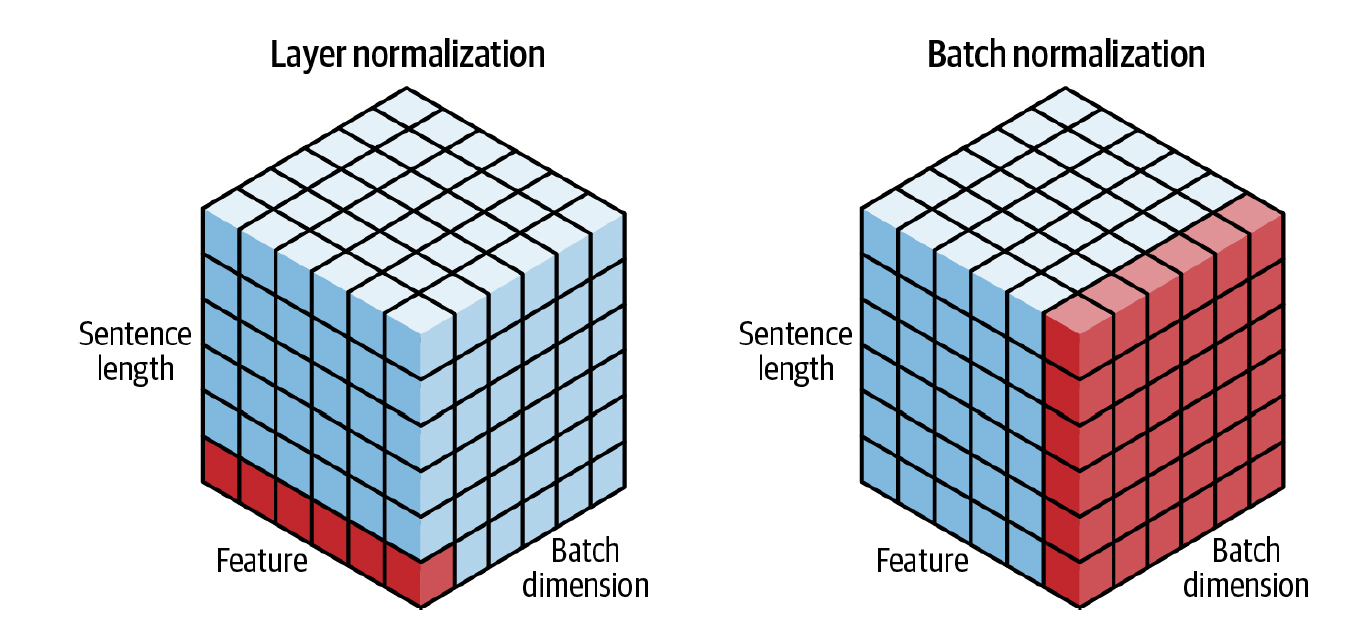


Assume the hidden representation for token $t$ is a vector:

$$
x_t \in \mathbb{R}^{d}.
$$

LayerNorm is applied **independently for each token** (no batch statistics needed).

### Compute mean and variance across features

Mean:

$$
\mu_t = \frac{1}{d}\sum_{i=1}^{d} x_{t,i}.
$$

Variance:

$$
\sigma_t^2 = \frac{1}{d}\sum_{i=1}^{d}\left(x_{t,i}-\mu_t\right)^2.
$$

### Normalize the vector

$$
\hat{x}_{t,i} = \frac{x_{t,i}-\mu_t}{\sqrt{\sigma_t^2+\epsilon}},
\quad i=1,\dots,d.
$$

Here $\epsilon$ is a small constant (e.g., $10^{-5}$) to avoid division by zero.


### Apply learned scale and shift

LayerNorm then applies learnable parameters:

$$
\gamma \in \mathbb{R}^{d},\quad \beta \in \mathbb{R}^{d},
$$

so the final output is:

$$
\mathrm{LN}(x_t)_i = \gamma_i \hat{x}_{t,i} + \beta_i.
$$

This keeps the representation normalized **but still flexible**, because the model can learn to re-scale or shift each feature dimension.

### Why LayerNorm is used in Transformers

1. **Stabilizes activations across depth**  
   Transformers add residuals and apply attention/MLPs repeatedly. LN prevents hidden vectors from drifting to very large or very small scales.

2. **Improves optimization and gradient flow**  
   Normalized inputs make the attention and MLP sublayers easier to train, especially for deep stacks.

3. **Works well for autoregressive generation and small batches**  
   Unlike BatchNorm, LayerNorm does not depend on batch statistics, so it behaves consistently even when generating one token at a time.

## **The Transformer Block**
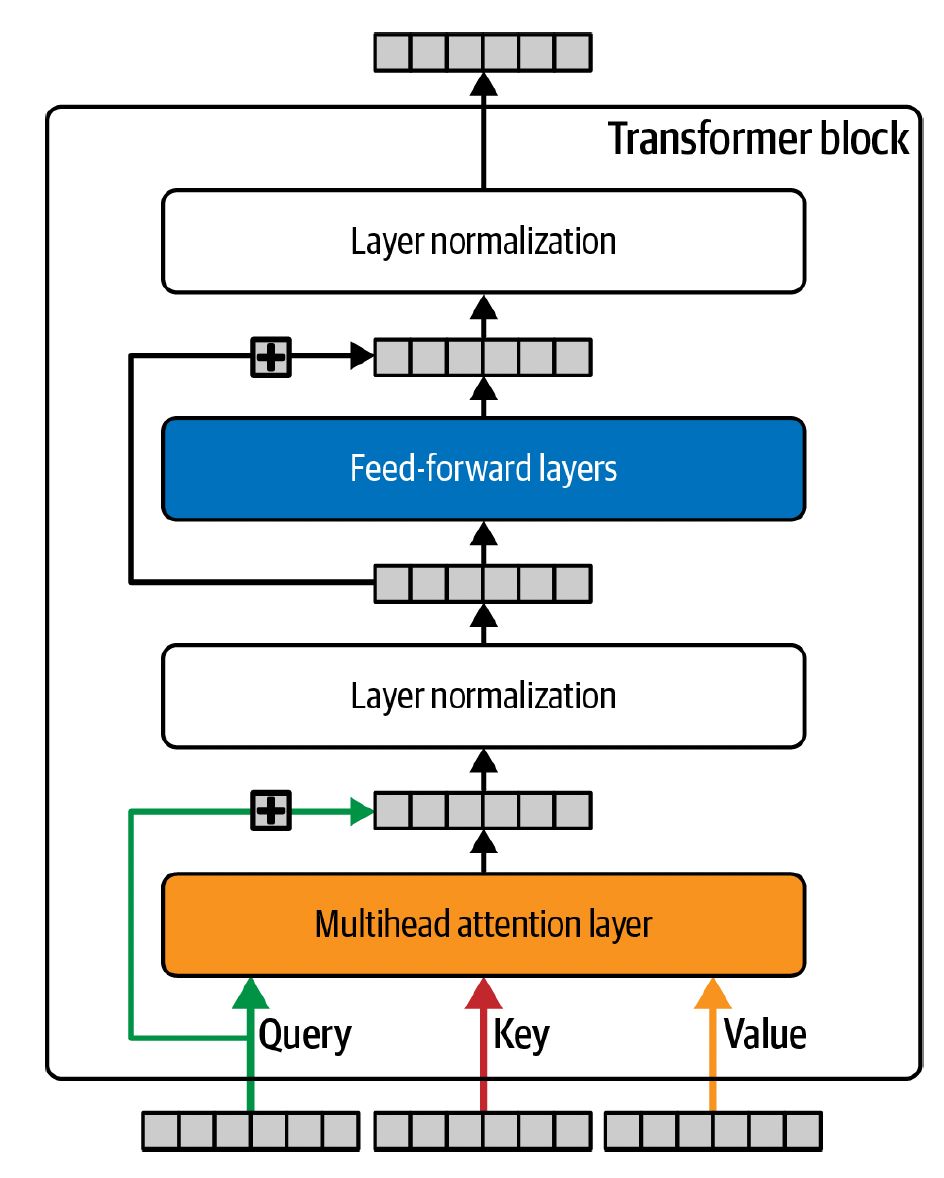

**Source:**

### Overall input/output of the block
- **Input:** a matrix of token representations  
  $X \in \mathbb{R}^{T \times d}$ 
  where $T$ is the number of tokens and $d$ is the hidden size. Row $x_t$ is token $t$'s vector.
- **Output:** a new matrix  
  $X_{\text{out}} \in \mathbb{R}^{T \times d}$ same shape as $X$, but each token vector is more contextual.

### Multi-head attention layer (orange)

#### Input
- **Input:** the current sequence representations  $X \in \mathbb{R}^{T \times d}.$

#### What it produces internally
It creates three derived sequences:
- **Queries:** $Q \in \mathbb{R}^{T \times d_k}$
- **Keys:** $K \in \mathbb{R}^{T \times d_k}$
- **Values:** $V \in \mathbb{R}^{T \times d_v}$

These come from learned linear projections of $X$:
$
Q = XW_Q,\quad K = XW_K,\quad V = XW_V.
$

#### Output
- **Output:** a new sequence  
  $Y \in \mathbb{R}^{T \times d}$ (after combining heads and a final projection). Each row $y_t$ is a weighted mixture of value vectors from other tokens.

#### Why it is needed
- Lets each token **look at other tokens** and pull in needed information.
- Creates short paths for long-range dependencies (token $t$ can directly use token $j$).
- Multiple heads let the model learn different relationships in parallel (syntax, coreference, etc.).

### Residual (skip) connection around attention (green loop + plus box)

#### Input
- The original sequence $X$
- The attention output $Y = \mathrm{MHA}(X)$

#### Output
- The sum (same shape):
$
X + Y \in \mathbb{R}^{T \times d}.
$

#### Why it is needed
- Preserves useful information from $X$.
- Stabilizes training and improves gradient flow.
- Lets the attention sublayer learn refinements instead of rewriting everything.

### Layer normalization after attention (first LN box)

#### Input
- The post-residual result:
$
X + \mathrm{MHA}(X).
$

#### Output
- A normalized sequence:
$
X_1 = \mathrm{LN}(X + \mathrm{MHA}(X)) \in \mathbb{R}^{T \times d}.
$

#### Why it is needed
- Stabilizes activation scale across layers.
- Makes optimization more reliable.
- Works well even for small batches and autoregressive generation.

### Feed-forward layers (blue block, FFN / MLP)

#### Input
- The normalized sequence:
$
X_1 \in \mathbb{R}^{T \times d}.
$

#### Output
- A transformed sequence:
$
F = \mathrm{FFN}(X_1) \in \mathbb{R}^{T \times d},
$

where the same MLP is applied **independently to each token**.

A common FFN form is:
$
\mathrm{FFN}(x) = W_2\,\sigma(W_1x + b_1) + b_2.
$

#### Why it is needed
- Attention mainly mixes information across tokens (weighted sums).
- FFN adds **nonlinearity** and **feature creation** per token.
- Intuition: attention chooses what to read; FFN computes with what was read.

### Residual (skip) connection around the FFN (black loop + plus box)

#### Input
- The FFN input $X_1$
- The FFN output $\mathrm{FFN}(X_1)$

#### Output
- The sum:
$
X_1 + \mathrm{FFN}(X_1) \in \mathbb{R}^{T \times d}.
$

#### Why it is needed
- Same reason as the attention residual: stable deep training and preserving information.

### Layer normalization after FFN (top LN box)

#### Input
- The post-residual FFN result:
$
X_1 + \mathrm{FFN}(X_1).
$

#### Output
- The final block output:
$
X_{\text{out}} = \mathrm{LN}(X_1 + \mathrm{FFN}(X_1)) \in \mathbb{R}^{T \times d}.
$

#### Why it is needed
- Keeps the output well-scaled before the next block.
- Prevents activation drift as many blocks are stacked.

### Summary of the whole block (matching the diagram)

- **Attention sublayer:**
$
X_1 = \mathrm{LN}(X + \mathrm{MHA}(X)).
$

- **FFN sublayer:**
$
X_{\text{out}} = \mathrm{LN}(X_1 + \mathrm{FFN}(X_1)).
$

## Simple Implementation of a Transformer Block

Now we implement a full-fledged implementation of a **Transformer**. We only require **PyTorch**. Matplotlib is optional (used for a small visualization).

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [ ]:

import sys, platform
print(sys.version)
print(platform.platform())

try:
    import torch
    print("torch:", torch.__version__)
    print("cuda:", torch.cuda.is_available())
except Exception as e:
    print("torch import failed:", e)

In [ ]:

# If you need installs (uncomment):

import math
import time
import random
import urllib.request
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import matplotlib.pyplot as plt
    HAVE_PLT = True
except Exception:
    HAVE_PLT = False

# Reproducibility
seed = 1337
random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("device:", device)

## Download a simple text corpus

We will use **Tiny Shakespeare** (popular small LM demo corpus). If download fails, we fall back to a short built-in text. We will train the model to **predict** words based on this **corpus**. 

In [ ]:

def download_text(url: str, timeout: int = 15) -> Optional[str]:
    try:
        with urllib.request.urlopen(url, timeout=timeout) as r:
            return r.read().decode("utf-8", errors="replace")
    except Exception as e:
        print("[download] failed:", e)
        return None

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = download_text(url)

if text is None:
    text = (
        "To be, or not to be, that is the question:\n"
        "Whether 'tis nobler in the mind to suffer\n"
        "The slings and arrows of outrageous fortune...\n"
    )
    print("[data] using fallback mini-corpus")

print("chars:", len(text))
print("preview:\n", text[:600])

## Byte-Pair Encoding (BPE) Tokenization

Modern language models do not operate directly on raw characters or raw words.  Instead, they convert text into **tokens** drawn from a fixed vocabulary.

**BPE (Byte-Pair Encoding)** is a widely used tokenization method that builds a vocabulary of **subword units**.  
It provides a practical balance between:

- character-level modeling (very flexible, but long sequences)
- word-level modeling (short sequences, but many unknown words)

### The problem BPE solves

If we tokenize by **words**, we get:
- a huge vocabulary (millions of words)
- an out-of-vocabulary problem (unknown words, spelling variants, names)

If we tokenize by **characters**, we get:
- a tiny vocabulary (letters + punctuation)
- but sequences become much longer (harder and slower to model)

BPE gives a middle ground:
- **frequent patterns** become single tokens
- **rare words** are split into smaller pieces that are still in-vocabulary

### Core idea of BPE

BPE starts with a vocabulary of small symbols (often characters, or bytes) and repeatedly:

1. counts all adjacent symbol pairs in the training data
2. merges the most frequent pair into a new symbol
3. repeats until a target vocabulary size is reached

This creates tokens like:

- `"th"`, `"the"`, `"ing"`, `"tion"`, `"elephant"`, etc.

So the tokenizer learns common substrings automatically.

### The BPE merge algorithm

Let the initial symbol sequence for a word be:

$
w = (c_1, c_2, \dots, c_n),
$

where each $c_i$ is a base symbol (character or byte).

#### 1) Count adjacent pairs
Count occurrences of all adjacent pairs:

$
(c_1,c_2), (c_2,c_3), \dots, (c_{n-1},c_n).
$

Across the whole corpus, find the most frequent pair:

$
(a,b) = \arg\max_{(u,v)} \mathrm{count}(u,v).
$

#### 2) Merge the most frequent pair
Create a new symbol:

$
ab,
$

and replace every occurrence of $a,b$ with $ab$.

#### 3) Repeat
Repeat count-and-merge until the vocabulary size reaches a chosen limit.

### Simple example

Suppose our dataset contains these words (shown as characters with an end marker `</w>`):

- `low</w>`
- `lower</w>`
- `newest</w>`
- `widest</w>`

Start with character tokens:

- `l o w </w>`
- `l o w e r </w>`
- `n e w e s t </w>`
- `w i d e s t </w>`

If `e s` is the most frequent adjacent pair, merge:

- `e s` $\rightarrow$ `es`

Then `es t` might be merged to `est`, and so on.  
Eventually, you may learn tokens like:

- `low`, `lower`, `est`, `new`, `wid`, etc.

Rare words are represented as combinations of learned subwords.

### Byte-level BPE in GPT-2

Standard BPE often starts from **characters**, but GPT-2 uses **byte-level BPE**:

- The base vocabulary is all 256 possible byte values $0,\dots,255$.
- Text is converted to UTF-8 bytes.
- BPE merges are learned over byte sequences.

#### Why byte-level matters
- Any Unicode text can be represented as bytes (no unknown characters).
- It avoids complicated language-specific preprocessing.
- It guarantees that every possible string is tokenizable.

So in byte-level BPE, the initial tokens are bytes, and merges build up larger byte sequences that correspond to readable substrings.

#### Encoding (tokenizing) with BPE after training

Once the merge rules are learned, tokenizing new text works like this:

1. start from base symbols (characters or bytes)
2. apply the learned merges in order (highest priority merges first)
3. output the final list of token ids

So tokenization is a deterministic “apply merges” procedure.

### Why BPE is a good fit for language models

BPE gives you:
- a fixed vocabulary size (controls model size and speed)
- no unknown words (rare words are decomposed)
- shorter sequences than characters
- better handling of names, spelling variations, and morphologically rich languages

### Summary
BPE tokenization learns a vocabulary of frequent subword patterns by repeatedly merging common adjacent symbol pairs, giving efficient and flexible token representations for language models.

## **GPT‑2 uses byte-level BPE**:
Below is a compact, educational byte-level BPE implementation.

In [ ]:

class ByteBPE:
    '''
    Minimal byte-level BPE:
    - Base vocab: 256 byte tokens [0..255]
    - Learn merges on training corpus to reach vocab_size
    - Encode by applying merges in learned order (slow but OK for small corpora)
    '''
    def __init__(self, vocab_size: int = 2000):
        assert vocab_size >= 256
        self.vocab_size = vocab_size
        self.merges: List[Tuple[int, int, int]] = []  # (a, b, new_id) in learned order
        self.id_to_bytes: Dict[int, bytes] = {i: bytes([i]) for i in range(256)}
        self.bytes_to_id: Dict[bytes, int] = {bytes([i]): i for i in range(256)}

    @staticmethod
    def _pair_frequencies(seqs: List[List[int]]) -> Dict[Tuple[int, int], int]:
        freqs: Dict[Tuple[int, int], int] = {}
        for s in seqs:
            for i in range(len(s) - 1):
                p = (s[i], s[i + 1])
                freqs[p] = freqs.get(p, 0) + 1
        return freqs

    @staticmethod
    def _merge_pair(seq: List[int], a: int, b: int, new_id: int) -> List[int]:
        out: List[int] = []
        i = 0
        L = len(seq)
        while i < L:
            if i < L - 1 and seq[i] == a and seq[i + 1] == b:
                out.append(new_id)
                i += 2
            else:
                out.append(seq[i])
                i += 1
        return out

    def train(self, text: str, verbose_every: int = 200) -> None:
        data = text.encode("utf-8", errors="replace")
        # Simple chunking into "documents" for pair stats
        chunk = 2000
        seqs = [list(data[i : i + chunk]) for i in range(0, len(data), chunk) if len(data[i : i + chunk]) > 2]

        next_id = 256
        target_merges = self.vocab_size - 256

        for m in range(target_merges):
            freqs = self._pair_frequencies(seqs)
            if not freqs:
                break
            (a, b), count = max(freqs.items(), key=lambda kv: kv[1])
            if count < 2:
                break

            new_id = next_id
            next_id += 1

            # Record bytes expansion for decode
            self.id_to_bytes[new_id] = self.id_to_bytes[a] + self.id_to_bytes[b]
            self.bytes_to_id[self.id_to_bytes[new_id]] = new_id

            # Apply merge to all sequences
            seqs = [self._merge_pair(s, a, b, new_id) for s in seqs]
            self.merges.append((a, b, new_id))

            if verbose_every and (m + 1) % verbose_every == 0:
                print(f"[BPE] merges learned: {m+1}/{target_merges}")

        print(f"[BPE] final vocab size: {len(self.id_to_bytes)} (target {self.vocab_size})")

    def encode(self, text: str) -> List[int]:
        seq = list(text.encode("utf-8", errors="replace"))
        for (a, b, new_id) in self.merges:
            seq = self._merge_pair(seq, a, b, new_id)
        return seq

    def decode(self, ids: List[int]) -> str:
        b = b"".join(self.id_to_bytes[i] for i in ids)
        return b.decode("utf-8", errors="replace")


def token_repr(tok_id: int, tokenizer: ByteBPE) -> str:
    bb = tokenizer.id_to_bytes[tok_id]
    s = bb.decode("utf-8", errors="replace")
    s = s.replace("\n", "\\n").replace("\t", "\\t").replace("\r", "\\r")
    if len(s) > 30:
        s = s[:27] + "..."
    return f"id={tok_id:4d} bytes={list(bb)[:10]}{'...' if len(bb)>10 else ''} text='{s}'"

### Train BPE on the corpus
BPE must be trained on a specific corpus of text. This will allow us to determine essentually how to **tokenize** this specific **corpus**. 

In [ ]:
# we need vocabulary size because we are learning merges to reach that vocab size

vocab_size = 1200  # increase for better compression (slower training)
tokenizer = ByteBPE(vocab_size=vocab_size)

t0 = time.time()
tokenizer.train(text, verbose_every=200)
print("BPE training seconds:", round(time.time() - t0, 2))

print("Example base byte tokens:")
for tid in [ord(' '), ord('e'), ord('\n')]:
    print(" ", token_repr(tid, tokenizer))

### BPE Encode / Decode examples

Note that the endoding encodes the input text into a number of tokens and the output is **not** the token (e.g., ROME) but an **id** (e.g., 923) of the **token**. 

In [ ]:

sample = "ROMEO: But, soft! what light through yonder window breaks?\n"
ids = tokenizer.encode(sample)

print("Original:", repr(sample))
print("Token count:", len(ids))
print("First 30 token IDs:", ids[:30])
print("\nDecoded:", repr(tokenizer.decode(ids)))

print("\nFirst 20 tokens (expanded):")
for tid in ids[:20]:
    print("  ", token_repr(tid, tokenizer))

### Show how merges change the tokenization (illustration)

In [ ]:

def encode_with_first_n_merges(text: str, tokenizer: ByteBPE, n_merges: int) -> List[int]:
    seq = list(text.encode("utf-8", errors="replace"))
    for (a, b, new_id) in tokenizer.merges[:n_merges]:
        seq = tokenizer._merge_pair(seq, a, b, new_id)
    return seq

demo = "To be, or not to be."
print("demo text:", demo)

for n in [0, 10, 50, 150]:
    ids_n = encode_with_first_n_merges(demo, tokenizer, n)
    pieces = [tokenizer.id_to_bytes[i].decode("utf-8", errors="replace").replace("\n","\\n") for i in ids_n]
    print(f"\nFirst {n} merges -> {len(ids_n)} tokens:")
    print(pieces)

## Attention: A Simple Example

Single-head attention is:
$$
\text{Att}(Q,K,V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

**Causal masking** prevents position $t$ from attending to future positions $>t$.

In [ ]:

torch.set_printoptions(precision=3, sci_mode=False)

T = 4
# the dimension of the model and keys/values is small for clarity; in practice these would be larger
d_model = 6
d_k = d_model  # single head for clarity

# Fixed input sequence of token embeddings (T x d_model)
X = torch.tensor([
    [ 1.0,  0.0,  0.5, -1.0,  0.0,  0.2],
    [ 0.0,  1.0, -0.5,  0.0,  1.0, -0.2],
    [ 1.0,  1.0,  0.0,  0.5, -0.5,  0.1],
    [-0.5,  0.2,  1.0,  0.0,  0.5,  1.0],
], dtype=torch.float32)  # shape: (T=4, d_model=6)

# The learned projection matrices for queries, keys, and values (d_model x d_k)
Wq = torch.randn(d_model, d_k)
Wk = torch.randn(d_model, d_k)
Wv = torch.randn(d_model, d_k)

# Compute queries, keys, values
Q = X @ Wq
K = X @ Wk
V = X @ Wv

# Compute attention scores (T x T)
scores = (Q @ K.T) / math.sqrt(d_k)

# Causal mask to prevent attending to future tokens
causal_mask = torch.tril(torch.ones(T, T)).bool()
masked_scores = scores.masked_fill(~causal_mask, float("-inf"))

# Softmax to get attention weights, then weighted sum of values
# Note: the masked scores will have -inf for disallowed positions, so softmax will give zero weight to those
# This is the core of the self-attention mechanism: each token's output is a weighted sum of the value vectors, 
# where the weights are determined by the compatibility of the query with the keys, and masked to prevent looking ahead.
# Softmax is row-wise, so each token's weights sum to 1 over the allowed positions.

A = torch.softmax(masked_scores, dim=-1)

# Mutiply weights by values to get output (T x d_k)
Y = A @ V

print("Scores (unmasked):\n", scores)
print("\nCausal mask (True=allowed):\n", causal_mask)
print("\nScores (masked):\n", masked_scores)
print("\nAttention weights:\n", A)
print("\nOutput = A @ V:\n", Y)

In [ ]:
!pip install matplotlib --quiet

In [ ]:
import torch, math
import matplotlib.pyplot as plt

X_np = X.numpy()
Y_np = Y.detach().numpy()
D_np = (Y - X).detach().numpy()

token_labels = [f"token {i+1}" for i in range(T)]
dim_labels = [f"d{i+1}" for i in range(d_model)]

# Heatmaps with clean integer ticks
plt.figure(figsize=(12,4))

ax1 = plt.subplot(1,3,1)
im1 = ax1.imshow(X_np, aspect='auto')
ax1.set_title("Input embeddings X (T×d)")
ax1.set_xlabel("Embedding dim")
ax1.set_ylabel("Token")
ax1.set_xticks(range(d_model))
ax1.set_xticklabels(dim_labels)
ax1.set_yticks(range(T))
ax1.set_yticklabels(token_labels)
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

ax2 = plt.subplot(1,3,2)
im2 = ax2.imshow(Y_np, aspect='auto')
ax2.set_title("Attention output Y = A·V (T×d)")
ax2.set_xlabel("Embedding dim")
ax2.set_ylabel("Token")
ax2.set_xticks(range(d_model))
ax2.set_xticklabels(dim_labels)
ax2.set_yticks(range(T))
ax2.set_yticklabels(token_labels)
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = plt.subplot(1,3,3)
im3 = ax3.imshow(D_np, aspect='auto')
ax3.set_title("Changes to Embeddings (Y − X)")
ax3.set_xlabel("Embedding dim")
ax3.set_ylabel("Token")
ax3.set_xticks(range(d_model))
ax3.set_xticklabels(dim_labels)
ax3.set_yticks(range(T))
ax3.set_yticklabels(token_labels)
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

plt.figure(figsize=(5.2,4))
im = plt.imshow(A.detach().numpy(), aspect='auto')
plt.title("Attention weights A (T×T, rows sum to 1)")
plt.xlabel("Key token")
plt.ylabel("Query token")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(T), token_labels)
plt.yticks(range(T), token_labels)
plt.tight_layout()
plt.show()


print("X shape:", tuple(X.shape))
print("A shape:", tuple(A.shape))
print("Y shape:", tuple(Y.shape))

 

## GELU MLP in a Transformer (FFN)

Inside each Transformer block, the **MLP / Feed-Forward Network (FFN)** is a position-wise network applied **independently to each token vector**. It adds **nonlinearity** and **capacity** after attention has mixed information across tokens.

### Input and output (per token)

For token $t$, let its vector be:

$
x_t \in \mathbb{R}^{d}.
$

The FFN outputs another vector with the **same dimension**:

$
\mathrm{FFN}(x_t) \in \mathbb{R}^{d}.
$

### The standard Transformer MLP form

The most common FFN uses two linear layers with an activation in between:

$
\mathrm{FFN}(x) = W_2 \, \phi(W_1 x + b_1) + b_2,
$

where:
- $W_1 \in \mathbb{R}^{d_{\text{ff}} \times d}$ (expands dimension)
- $b_1 \in \mathbb{R}^{d_{\text{ff}}}$
- $W_2 \in \mathbb{R}^{d \times d_{\text{ff}}}$ (projects back)
- $b_2 \in \mathbb{R}^{d}$
- $\phi(\cdot)$ is typically **GELU** in GPT-style models

Typically:

$
d_{\text{ff}} \approx 4d.
$

So the MLP expands the representation (more capacity), applies a nonlinearity, then compresses it back.

### What is GELU?

**GELU** stands for **Gaussian Error Linear Unit**. It behaves like a smooth, probabilistic version of ReLU.

Exact definition:

$
\mathrm{GELU}(x) = x \, \Phi(x),
$

where $\Phi(x)$ is the CDF of a standard normal distribution:

$
\Phi(x) = \int_{-\infty}^{x} \frac{1}{\sqrt{2\pi}} e^{-t^2/2}\,dt.
$

A commonly used approximation (fast and very accurate) is:

$
\mathrm{GELU}(x) \approx 0.5x \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}\left(x + 0.044715x^3\right)\right)\right).
$

### Why use GELU instead of ReLU?

#### Smooth gating rather than hard thresholding
- ReLU is a hard gate: it outputs 0 for all negative inputs.
- GELU smoothly down-weights negative inputs instead of killing them entirely.

So GELU behaves like:

> “keep a fraction of the signal depending on how positive it is.”

#### Better optimization in practice for Transformers
In many Transformer LMs, GELU empirically trains better than ReLU:
- smoother gradients
- slightly better accuracy/perplexity

### Why do we need an MLP at all (if we already have attention)?

Attention mostly does **weighted averaging** of value vectors:

$
y_t = \sum_{j} \alpha_{t,j} v_j,
$

which is primarily a mixing operation.

The FFN/MLP then:
- creates new nonlinear features from that mixed representation
- increases model capacity per token
- helps the model compute transformations like “is this token part of a noun phrase?” or “is this context indicating size?”

A good mental model:

- **Attention:** “What information should I read from other tokens?”
- **MLP (with GELU):** “How should I transform and combine that information into useful features?”

### Matrix form over the whole sequence

If $X \in \mathbb{R}^{T \times d}$ is the sequence matrix:

$
\mathrm{FFN}(X) = \mathrm{GELU}(XW_1^\top + \mathbf{1}b_1^\top)\,W_2^\top + \mathbf{1}b_2^\top,
$

where $\mathbf{1} \in \mathbb{R}^{T}$ broadcasts biases across tokens. Broadcasting means that it **repeats the same bias vector for each token**.

### Summary
The Transformer GELU-MLP is a **two-layer, per-token network** that expands the hidden dimension, applies **GELU** for smooth nonlinear gating, then projects back—adding crucial nonlinear compute beyond attention’s mixing.

## How training works with GPT-style models

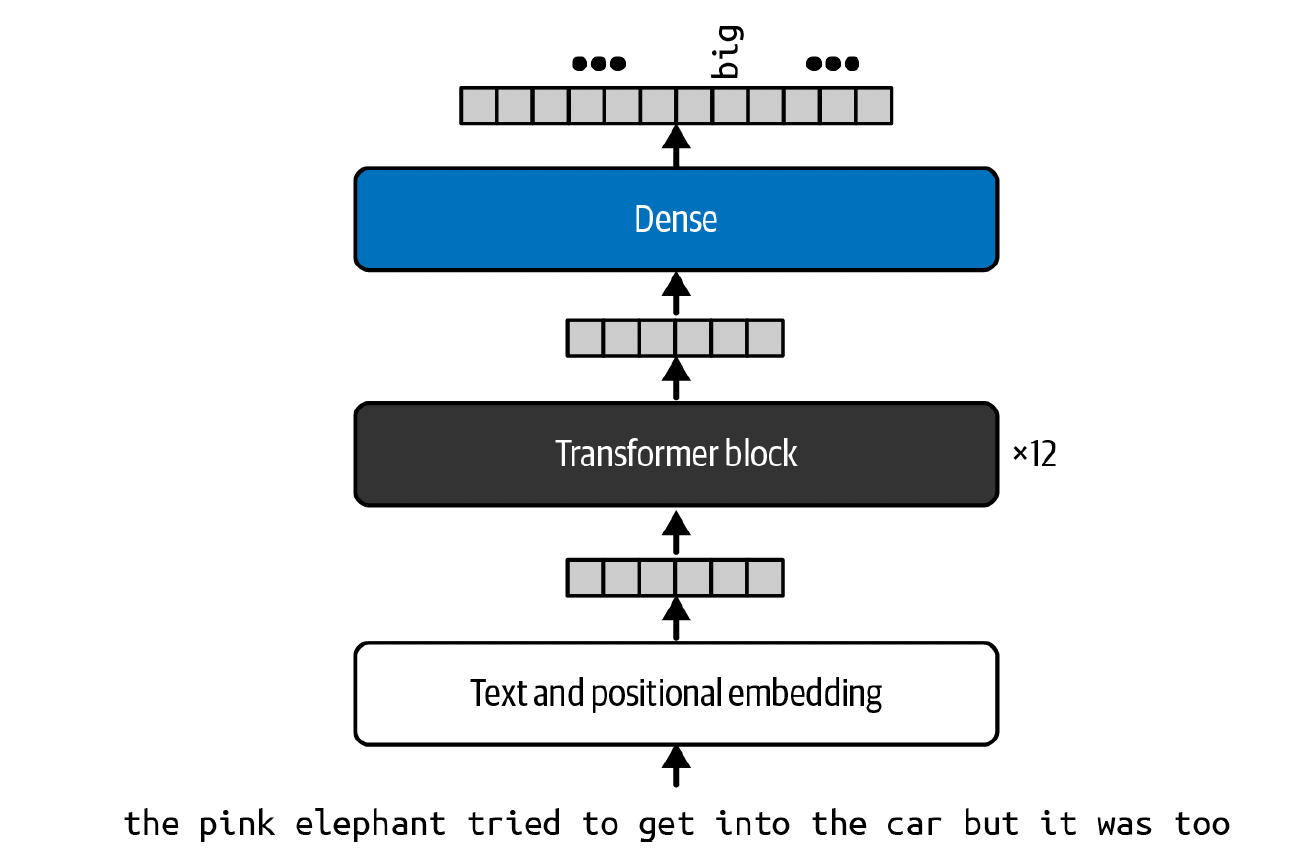

A GPT-style language model is trained to do **next-token prediction**.

Suppose you have a tokenized sequence:

$$
s_1, s_2, \dots, s_T,
\quad
s_t \in \{1,\dots,V\}.
$$

### Build training pairs by shifting by one

We form:

- **Input** sequence $x$:
$
x = [s_1, s_2, \dots, s_{T-1}]
$

- **Target** sequence $y$ (shifted left by one):
$
y = [s_2, s_3, \dots, s_T]
$

So each position $t$ in $x$ is asked to predict the **next** token:

$
\text{predict } y_t = s_{t+1} \text{ from } x_{\le t} = [s_1,\dots,s_t].
$

In code, this is often done with contiguous blocks:
- $x = \text{tokens}[i : i+T]$
- $y = \text{tokens}[i+1 : i+T+1]$

### The model produces logits for every position

Given $x$, the Transformer outputs a hidden state for each position, then maps it to vocabulary logits:

$
H = \mathrm{Transformer}(x) \in \mathbb{R}^{(T-1)\times d}.
$

Final linear “LM head”:

$
Z = HW_{\mathrm{out}} + b
\in \mathbb{R}^{(T-1)\times V}.
$

- Row $Z_t \in \mathbb{R}^{V}$ contains the logits for predicting $y_t$.

Convert logits to probabilities with softmax:

$
p_\theta(\cdot \mid x_{\le t}) = \mathrm{softmax}(Z_t).
$

### Cross-entropy compares predicted distribution to the true next token

Each target $y_t$ is a single correct class index in $\{1,\dots,V\}$.  
Cross-entropy for one position $t$ is:

$$
\ell_t
=
-\log p_\theta(y_t \mid x_{\le t}).
$$

Since:

$$
p_\theta(y_t \mid x_{\le t})
=
\frac{\exp(Z_{t,y_t})}{\sum_{v=1}^{V}\exp(Z_{t,v})},
$$

the loss can be written as:

$$
\ell_t
=
-\; Z_{t,y_t}
+
\log\left(\sum_{v=1}^{V} \exp(Z_{t,v})\right).
$$

### Total loss is summed (or averaged) over all positions (and batch)

For a single sequence:

$$
\mathcal{L}(\theta)
=
\sum_{t=1}^{T-1} \ell_t
=
-\sum_{t=1}^{T-1}\log p_\theta(y_t \mid x_{\le t}).
$$

For a batch of sequences, we sum/average across batch and time. This corresponds to the autoregressive maximum likelihood objective:

$$
p_\theta(s_{1:T})
=
\prod_{t=1}^{T} p_\theta(s_t \mid s_{<t}),
$$

trained by minimizing negative log-likelihood.

### What backprop updates

The cross-entropy loss provides gradients that update:

- the final output projection $W_{\mathrm{out}}, b$ (so logits become accurate)
- all Transformer block parameters (attention + MLP + LayerNorm)
- token and positional embeddings

So the model learns internal representations that make the correct next token high-probability at each position.

## A small GPT‑2 style Decoder-only Transformer

This impements:

- Token embeddings $W_e$ and learned positional embeddings $W_p$
- Pre-LN Transformer blocks with **masked multi-head self-attention**
- GELU MLP
- Weight tying between embedding and LM head

In [ ]:

# vocab_size: size of the token vocabulary
# block_size: maximum context length (sequence length)
# n_layer: number of transformer blocks
# n_head: number of attention heads
# n_embd: dimensionality of token embeddings and model hidden states

@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int = 128
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 256
    dropout: float = 0.1

# This is a minimal implementation of the core components of a GPT-like transformer model, 
# focusing on the causal self-attention mechanism and the MLP feedforward network. 
# The Block class combines these with layer normalization and residual connections, 
# and the GPT class puts everything together with token and positional embeddings, 
# and a final linear layer for language modeling.

class CausalSelfAttention(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        assert cfg.n_embd % cfg.n_head == 0
        self.cfg = cfg
        # Each head has dimension head_dim = n_embd // n_head
        self.head_dim = cfg.n_embd // cfg.n_head
        
        # In practice, we would have separate projection matrices for each head, but 
        # for simplicity we use one big matrix and split it later.
        
        # it is 3 * n_embd because we compute q, k, v in one go for efficiency
        # the qkv linear layer will take input of shape (B, T, n_embd) and output (B, T, 3 * n_embd)
        # each of q, k, v will then be of shape (B, T, n_embd) after splitting and have their own 
        # bias terms. This is a common optimization to compute all three in one matrix multiply.

        self.qkv = nn.Linear(cfg.n_embd, 3 * cfg.n_embd, bias=True)
        self.proj = nn.Linear(cfg.n_embd, cfg.n_embd, bias=True)

        # Dropout for attention weights and output projection
        self.attn_drop = nn.Dropout(cfg.dropout)
        self.resid_drop = nn.Dropout(cfg.dropout)
        
        # mask to prevent attention to future tokens (shape: 1, 1, block_size, block_size)
        mask = torch.tril(torch.ones(cfg.block_size, cfg.block_size)).view(1, 1, cfg.block_size, cfg.block_size)
        
        # register as buffer so it gets moved to the correct device with the model and is not a parameter
        # register_buffer is used for tensors that are not learnable parameters but should be part of the model 
        # state (e.g. moved to GPU with the model, saved in checkpoints)

        self.register_buffer("causal_mask", mask)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x has shape (B, T, C) where B=batch size, T=sequence length, C=n_embd
        B, T, C = x.shape

        # do the qkv projection in one go, then split into q, k, v
        qkv = self.qkv(x)

        # now we have the big qkv tensor of shape (B, T, 3 * n_embd), we split it into q, k, v 
        # each of shape (B, T, n_embd), dim=2 because the last dimension is the one we want to split
        # last dimension of qkv is 3 * n_embd, we split it into 3 parts of size n_embd each for q, k, v
        
        q, k, v = qkv.split(C, dim=2)

        # now we have q, k, v each of shape (B, T, n_embd), we need to reshape them to separate the heads
        # we want to reshape to (B, T, n_head, head_dim) and then transpose to (B, n_head, T, head_dim) 
        # for attention computation. This allows us to compute attention for all heads in parallel using 
        # batch matrix multiplication. transpose(1, 2) moves the T dimension to the end so we can do 
        # batch matmul with k and v

        q = q.view(B, T, self.cfg.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.cfg.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.cfg.n_head, self.head_dim).transpose(1, 2)

        # calculate attention scores (B, n_head, T, T) by batch matrix multiplying q and k^T, 
        # then scale by sqrt(head_dim). transpose(-2, -1) on k swaps the last two dimensions so 
        # we get (B, n_head, head_dim, T) which allows us to do batch matmul with q to get 
        # (B, n_head, T, T) attention scores for all heads in parallel.

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # apply causal mask to prevent attending to future tokens; masked positions get -inf 
        # so that softmax gives them zero weight
        att = att.masked_fill(self.causal_mask[:, :, :T, :T] == 0, float("-inf"))
        
        # do the softmax to get attention weights, then apply dropout
        # this is done row-wise so that each query token's weights sum to 1 over the allowed key tokens
        # this is why dim=-1 is used in softmax, to apply it to the last dimension (the key token dimension)

        w = torch.softmax(att, dim=-1)
        w = self.attn_drop(w)

        # perform the weighted sum of the values; w has shape (B, n_head, T, T) and v has 
        # shape (B, n_head, T, head_dim) the result y will have shape (B, n_head, T, head_dim)
        y = w @ v

        # reshape y back to (B, T, n_embd) by first transposing to (B, T, n_head, head_dim) and then 
        # merging the last two dimensions. This combines the outputs of all heads back into a single 
        # vector for each token. The final linear projection then mixes the information from the heads

        y = y.transpose(1, 2).contiguous().view(B, T, C)

        # output projection and dropout. resid_drop is applied to the output of the attention before 
        # adding it back to the input (residual connection)because in the full transformer block
        # we have x = x + attn(x) and we want to apply dropout to the attn output before adding it to x.

        y = self.resid_drop(self.proj(y))

        return y


# The MLP (feedforward) part of the transformer block, which consists of two linear layers 
# with a nonlinearity in between.

class MLP(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        # The first linear layer expands the dimensionality from n_embd to 4 * n_embd, which is a 
        # common choice for the hidden layer size in the MLP.
        self.fc = nn.Linear(cfg.n_embd, 4 * cfg.n_embd)
        # The second linear layer projects back down to n_embd. This allows the MLP to mix information across 
        # the embedding dimensions and add nonlinearity, which is important for the model's expressiveness.
        self.proj = nn.Linear(4 * cfg.n_embd, cfg.n_embd)
        # Dropout is applied to the output of the MLP before adding it back to the input (residual connection)
        self.drop = nn.Dropout(cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc(x)
        x = F.gelu(x)
        x = self.proj(x)
        x = self.drop(x)
        return x

# A single transformer block, which consists of a layer norm, followed by causal self-attention,
# followed by another layer norm and an MLP feedforward network, with residual connections around each part.

class Block(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        
        # Layer normalization before attention and MLP is a common design choice in transformer blocks,
        # often referred to as "pre-norm". This helps with training stability. The residual connections 
        # are added after the attention and MLP, so the input to each is normalized before being processed.
        self.ln1 = nn.LayerNorm(cfg.n_embd)

        # The causal self-attention module computes the attention output for the block. 
        # It takes the normalized input, computes the attention, and produces an output of the same 
        # shape (B, T, n_embd).

        self.attn = CausalSelfAttention(cfg)

        # Another layer norm before the MLP, and then the MLP itself. The MLP takes the output of the attention,
        # applies a feedforward transformation, and produces an output of the same shape 
        # (B, T, n_embd).

        self.ln2 = nn.LayerNorm(cfg.n_embd)

        # The MLP is applied after the attention output and has its own residual connection. The final output of the block
        # is the input plus the attention output plus the MLP output, with layer norms applied before each. 
        # This allows the block to learn both local interactions (through attention) and more 
        # complex transformations
        self.mlp = MLP(cfg)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # The input x is first normalized and passed through the attention module, 
        # and the result is added back to x (residual connection).
        x = x + self.attn(self.ln1(x))
        # Then the result is normalized again and passed through the MLP, and that result 
        # is also added back to x.
        x = x + self.mlp(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.cfg = cfg
        
        # Token embedding layer maps token IDs to dense vectors of size n_embd.
        # The input to the model is a sequence of token IDs, and the embedding layer converts 
        # these to vectors that can be processed by the transformer blocks.
        # wte stands for "word token embedding" and wpe stands for "word position embedding".
        # Embeddings are a crucial part of the model as they allow it to learn a continuous representation 
        # of discrete tokens, which is essential for the model to learn patterns in the data.

        self.wte = nn.Embedding(cfg.vocab_size, cfg.n_embd)
        self.wpe = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.drop = nn.Dropout(cfg.dropout)

        # The transformer blocks are created in a list, and each block is an instance of the Block 
        # class defined above. The number of blocks is determined by cfg.n_layer. 
        # Each block will process the output of the previous block, allowing the model to learn hierarchical 
        # representations of the input sequence.

        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)])

        # Final layer norm before the output projection. This is a common design choice in transformer models,
        # to normalize the output of the last block before projecting to the vocabulary size for language modeling
        self.ln_f = nn.LayerNorm(cfg.n_embd)

        # The final linear layer (lm_head) projects the output of the last transformer block to the size 
        # of the vocabulary, which allows the model to produce logits for each token in the vocabulary 
        # at each position in the sequence. The bias is set to False because we will tie the weights of 
        # this layer to the token embedding layer,
        self.lm_head = nn.Linear(cfg.n_embd, cfg.vocab_size, bias=False)

        # weight tying: the weights of the output projection (lm_head) are tied to the token embedding 
        # weights (wte) meaning they are the same matrix. This is a common technique in language models 
        # that reduces the number of parameters and can improve performance.
        self.lm_head.weight = self.wte.weight  # weight tying
        
        # Initialize weights using the _init_weights method defined below, which applies a normal 
        # distribution to the weights of linear and embedding layers, and zeros to the biases. 
        # This is important for training stability
        self.apply(self._init_weights)

        # Educational residual scaling idea to make it easier to see the effect of each block in the 
        # early stages of training.
        with torch.no_grad():
            scale = 1.0 / math.sqrt(2 * cfg.n_layer)
            for b in self.blocks:
                b.attn.proj.weight.mul_(scale)
                b.mlp.proj.weight.mul_(scale)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    def forward(self, idx: torch.Tensor, targets: Optional[torch.Tensor] = None):

        # idx has shape (B, T) where B=batch size and T=sequence length; each element is a token ID
        B, T = idx.shape
        
        # check that the sequence length T does not exceed the model's block size, 
        # which is the maximum context length
        assert T <= self.cfg.block_size
        
        # create position indices for the sequence (shape: 1, T) and get token and position embeddings
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)

        # the input to the transformer blocks is the sum of the token embeddings and the position embeddings,
        # which allows the model to learn both the identity of the tokens and their positions in the sequence.
        x = self.wte(idx) + self.wpe(pos)
        x = self.drop(x)

        # pass the input through each of the transformer blocks in sequence
        for b in self.blocks:
            x = b(x)
        x = self.ln_f(x)

        # project the output of the last block to the vocabulary size to get logits for language modeling
        logits = self.lm_head(x)

        # loss is set to None if targets is not provided, otherwise compute cross-entropy loss between 
        # the logits and the targets
        loss = None
        if targets is not None:
            # logits has shape (B, T, vocab_size) and targets has shape (B, T), we need to reshape them to
            # (B*T, vocab_size) and (B*T) respectively for cross_entropy which expects 2D input for logits 
            # and 1D input for targets
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        # the model returns the logits for each token in the sequence, and optionally the loss 
        # if targets were provided
        return logits, loss

    # generate method for autoregressive generation of text. It takes an initial sequence of token IDs (idx)
    # and generates new tokens up to max_new_tokens by repeatedly feeding the current sequence through the
    # model and sampling from the output distribution to get the next token ID, which is then appended

    @torch.no_grad()
    def generate(self, idx: torch.Tensor, max_new_tokens: int, top_k: int = 50, temperature: float = 1.0) -> torch.Tensor:
        self.eval()
        for _ in range(max_new_tokens):
            # For each step of generation, we take the last block_size tokens from the current sequence 
            # (idx) as input to the model.
            idx_cond = idx[:, -self.cfg.block_size :]

            # We get the logits for the next token by passing idx_cond through the model. 
            # The logits will have shape (B, T, vocab_size),
            # where T is the length of idx_cond. We take the logits for the last token
            logits, _ = self(idx_cond)

            # We focus on the logits for the last token in the sequence (the most recent token) to predict 
            # the next token. The temperature parameter is used to control the randomness of the sampling process; 
            # higher temperature leads to more random sampling.

            logits = logits[:, -1, :] / max(temperature, 1e-8)

            # top_k sampling: we keep only the top_k tokens with the highest logits and set the rest to -inf so that
            # they are not sampled. This is a common technique to improve the quality of generated text
            # by limiting the sampling to a smaller set of likely tokens, which can help avoid generating 
            # low-probability tokens that may lead to incoherent text.

            if top_k is not None and top_k > 0:
                v, _ = torch.topk(logits, k=min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float("-inf")

            # probs is the probability distribution over the next token, obtained by applying softmax 
            # to the logits.
            probs = torch.softmax(logits, dim=-1)

            # We sample the next token ID from the probability distribution. torch.multinomial is used to sample
            # from the distribution defined by probs. num_samples=1 means we want to sample one token ID for 
            # each example in the batch. The result will have shape (B, 1)
            next_id = torch.multinomial(probs, num_samples=1)

            # We append the sampled next token ID to the current sequence of token IDs (idx) for each example
            # in the batch.
            idx = torch.cat([idx, next_id], dim=1)
        return idx

## Prepare tokenized dataset and batching

In [ ]:
# Now we have defined the tokenizer and the model, we can prepare the data for training. 
# We will encode the text using the ByteBPE tokenizer, split it into a training and validation set, 
# and create a simple data loader that can provide batches of token sequences for training.
all_tokens = tokenizer.encode(text)
print("Total tokens:", len(all_tokens))

# We will use the first 90% of the tokens for training and the remaining 10% for validation.
n = len(all_tokens)
split = int(0.9 * n)
train_tokens = torch.tensor(all_tokens[:split], dtype=torch.long)
val_tokens   = torch.tensor(all_tokens[split:], dtype=torch.long)

# We create instances of the LMData class for the training and validation sets, which will provide 
# a method to get batches of data for training.
class LMData:
    def __init__(self, tokens: torch.Tensor, block_size: int):
        self.tokens = tokens
        self.block_size = block_size

    def get_batch(self, batch_size: int, device: torch.device):
        # Randomly sample starting indices for the batch, ensuring that we have enough tokens left
        # for a full block
        ix = torch.randint(0, len(self.tokens) - self.block_size - 1, (batch_size,))
        
        # For each starting index, we create a sequence of input tokens (x) and target tokens (y)
        # where y is the input sequence shifted by one token to the right. This means that for 
        # each position in x, the corresponding position in y is the next token that the 
        # model should predict. This is the standard setup for training a language model, where t
        # he model learns to predict the next token given the previous tokens.
        # for example, if tokens are [A, B, C, D] and block_size is 3, then x would be [A, B, C] 
        # and y would be [B, C, D],
        x = torch.stack([self.tokens[i : i + self.block_size] for i in ix])
        y = torch.stack([self.tokens[i + 1 : i + self.block_size + 1] for i in ix])
        return x.to(device), y.to(device)

@torch.no_grad()
def estimate_loss(model, train_data, val_data, device, iters=20, batch_size=32):
    # Set the model to evaluation mode to disable dropout and other training-specific behavior
    model.eval()
    # We will compute the average loss on both the training and validation sets by sampling a number of 
    # batches
    losses = []
    for data in (train_data, val_data):
        l = []
        for _ in range(iters):
            xb, yb = data.get_batch(batch_size, device)
            _, loss = model(xb, yb)
            l.append(loss.item())
        losses.append(sum(l) / len(l))
    # After computing the losses, we set the model back to training mode so that it can continue to be 
    # trained.
    model.train()
    return losses[0], losses[1]

## Train the model 

In [ ]:

cfg = GPTConfig(
    vocab_size=len(tokenizer.id_to_bytes),
    block_size=128,
    n_layer=4,
    n_head=4,
    n_embd=256,
    dropout=0.1,
)
model = GPT(cfg).to(device)
print("Params (M):", sum(p.numel() for p in model.parameters()) / 1e6)

train_data = LMData(train_tokens, cfg.block_size)
val_data = LMData(val_tokens, cfg.block_size)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.1)

steps = 30000
batch_size = 32
eval_every = 150

t0 = time.time()
for step in range(1, steps + 1):
    xb, yb = train_data.get_batch(batch_size, device)
    _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    # Gradient clipping to prevent exploding gradients, which can be an issue in training deep
    # transformer models.
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    optimizer.step()

    if step % 50 == 0:
        print(f"step {step:4d}/{steps} | loss {loss.item():.4f}")

    if step % eval_every == 0:
        tr, va = estimate_loss(model, train_data, val_data, device, iters=20, batch_size=batch_size)
        print(f"[eval] step {step:4d} | train {tr:.4f} | val {va:.4f} | elapsed {time.time()-t0:.1f}s")

## Generate text

In [ ]:
# create an initial prompt and encode it using the tokenizer to get the starting token IDs for generation.

prompt = "ROMEO:"

# idx is the tensor of token IDs corresponding to the prompt, which will be used as the initial input to the model for generation.
idx = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long, device=device)

# We call the generate method of the model to produce new token IDs based on the initial prompt. 
# The generate method will produce a sequence of token IDs that represent the generated text, which 
# we then decode back into a string using the tokenizer's decode method.
# max_new_tokens specifies how many new tokens to generate
# top_k means that at each step of generation, we will only consider the top_k most likely next tokens to sample from
# which can help improve the quality of the generated text by avoiding low-probability tokens.
# temperature controls the randomness of the sampling process; higher temperature leads to more random sampling,
# while lower temperature makes the model more deterministic.
out = model.generate(idx, max_new_tokens=250, top_k=50, temperature=0.9)[0].tolist()

# Finally, we decode the generated token IDs back into a string to see the generated text.
print(tokenizer.decode(out))

## Inspect next-token probabilities

In [ ]:

def topk_next_tokens(prompt: str, k: int = 12):
    ids = tokenizer.encode(prompt)
    idx = torch.tensor([ids[-cfg.block_size:]], dtype=torch.long, device=device)
    with torch.no_grad():
        logits, _ = model(idx)
        probs = torch.softmax(logits[0, -1], dim=-1)

    p, tok = torch.topk(probs, k=k)
    rows = []
    for pi, ti in zip(p.tolist(), tok.tolist()):
        piece = tokenizer.id_to_bytes[ti].decode("utf-8", errors="replace").replace("\n","\\n")
        rows.append((ti, pi, piece))
    return rows

for tid, pi, piece in topk_next_tokens("ROMEO: ", k=12):
    print(f"id={tid:4d} prob={pi:.4f} piece='{piece}'")

## Common Autoregressive (next-token) foundation models

> **Autoregressive** means the model is trained to predict the next token:
> $p(x_{1:T})=\prod_{t=1}^{T}p(x_t\mid x_{<t}).$  
> Most modern LLM chat systems are deployed as **decoder-style Transformer** generators (often with MoE, tools, and multimodal input).

| Provider | Model (representative) | Open weights? | Encoder/Decoder style | Context window (typical) | Modalities | Notes / distinguishing traits |
|---|---|---:|---|---:|---|---|
| OpenAI | GPT-5 (plus GPT-5 mini / nano) | No | Decoder-style Transformer (AR) | 400K context, 128K max output | Text + vision (image input) | Frontier general model family; API variants for speed/cost |
| Anthropic | Claude Opus 4.6 | No | Decoder-style Transformer (AR) | 200K standard; 1M context in beta | Text (tool use); product supports agentic workflows | “Extended thinking” controls; long-context focus |
| Anthropic | Claude Sonnet 4.6 | No | Decoder-style Transformer (AR) | 200K standard; 1M context in beta | Text (tool use) | Balanced speed/intelligence tier; long-context planning |
| Google | Gemini 2.0 Flash | No | Autoregressive generative model (Transformer-based) | 1M context | Multimodal (text + images etc.) | Built-in tool use positioning; long-context support |
| DeepSeek (API) | deepseek-chat / deepseek-reasoner (V3.2) | No | Decoder-style Transformer (AR) | 128K context | Text | “Chat” vs “Reasoner” endpoints map to V3.2 non-thinking vs thinking mode |
| DeepSeek (open) | DeepSeek-V3 (MoE) | Yes | Decoder-style Transformer (AR), **MoE** | (commonly 128K in ecosystem) | Text | MoE with large total params / smaller active params; efficiency focus |
| DeepSeek (open) | DeepSeek-R1 | Yes | Decoder-style Transformer (AR) | (varies by hosting; see model card/docs) | Text | Reasoning-oriented family; includes distilled variants released to community |
| Meta | Llama 4 Scout | Partial (“open-weight” under Meta license) | Decoder-style Transformer (AR), **MoE** | 10M context | Text + image input; text output | Very long context emphasis |
| Meta | Llama 4 Maverick | Partial (“open-weight” under Meta license) | Decoder-style Transformer (AR), **MoE** | 1M context | Text + image input; text output | Strong general performance tier |
| Mistral | Mistral Large 3 | Yes (Apache 2.0) | Decoder-style Transformer (AR), **MoE** | 256K context | Multimodal (per model docs) | Open-weight flagship; large MoE with smaller active params |
| Alibaba / Qwen | Qwen2.5-1M (family) | Mixed (many open releases) | Decoder-style Transformer (AR) | 1M context | Text (plus ecosystem multimodal variants) | Long-context training/extrapolation line |
| xAI | Grok 4.1 Fast (reasoning / non-reasoning variants) | No | Decoder-style Transformer (AR) | 2M context | Text (+ agent tools; visual processing mentioned) | Tool-calling / agentic workflows; long-context RL emphasis |

## Sources (links)

OpenAI
- https://openai.com/gpt-5/
- https://developers.openai.com/api/docs/models/gpt-5
- https://developers.openai.com/api/docs/models/gpt-5-mini
- https://developers.openai.com/api/docs/models/gpt-5-nano

Anthropic (Claude 4.6)
- https://platform.claude.com/docs/en/about-claude/models/whats-new-claude-4-6
- https://www.anthropic.com/news/claude-opus-4-6
- https://www.anthropic.com/news/claude-sonnet-4-6

DeepSeek
- https://api-docs.deepseek.com/quick_start/pricing
- https://github.com/deepseek-ai/DeepSeek-V3
- https://huggingface.co/deepseek-ai/DeepSeek-R1

Meta (Llama 4)
- https://ai.meta.com/blog/llama-4-multimodal-intelligence/
- https://www.llama.com/models/llama-4/

Google (Gemini)
- https://docs.cloud.google.com/vertex-ai/generative-ai/docs/models/gemini/2-0-flash

Mistral
- https://docs.mistral.ai/models/mistral-large-3-25-12
- https://mistral.ai/news/mistral-3

Qwen
- https://qwenlm.github.io/blog/qwen2.5-1m/

xAI (Grok)
- https://x.ai/news/grok-4-1-fast
- https://x.ai/api

## Other Transformer architectures: decoder-only vs encoder-only vs encoder–decoder

| Architecture | Core idea | Attention pattern | Typical training objective | Strengths | Common uses | Representative model families |
|---|---|---|---|---|---|---|
| **Decoder-only** (causal LM) | Generate next token from the prefix | **Causal self-attention** (token $t$ attends only to $\le t$) | **Autoregressive next-token prediction** | Best for open-ended generation; scales well; natural for chat/code | Chatbots, text generation, code generation, long-form writing, agentic tool use | GPT (OpenAI), Claude (Anthropic), Gemini (Google; generative), Llama (Meta), Mistral, DeepSeek, Qwen, Grok |
| **Encoder-only** (bidirectional encoder) | Build contextual representations using full input context | **Bidirectional self-attention** (each token attends to all tokens) | **Masked language modeling** (or discriminative pretraining) | Strong understanding/representation learning; great for classification/retrieval | Classification, NER, search/ranking, embeddings, feature extraction | BERT, RoBERTa, DeBERTa, ELECTRA, ALBERT, ModernBERT-like families |
| **Encoder–decoder** (seq2seq) | Encode input, then decode output conditioned on encoded memory | Encoder: bidirectional self-attn; Decoder: causal self-attn + **cross-attention** to encoder | **Conditional generation** (teacher-forced seq2seq) | Excellent for input→output transforms; controllable generation | Translation, summarization, question answering, rewriting, structured generation | T5 / FLAN-T5, BART, mT5, UL2, MarianMT |

## Objectives (equations)

### Decoder-only (autoregressive) objective
Given tokens $s_{1:T}$:
$
p_\theta(s_{1:T}) = \prod_{t=1}^{T} p_\theta(s_t \mid s_{<t}),
$
and the negative log-likelihood loss:
$
\mathcal{L}(\theta) = -\sum_{t=1}^{T} \log p_\theta(s_t \mid s_{<t}).
$

### Encoder-only (masked language modeling)
Let $M$ be the set of masked positions. The model predicts only masked tokens:

$
\mathcal{L}(\theta) = -\sum_{t \in M} \log p_\theta(s_t \mid s_{\setminus M}).
$

### Encoder–decoder (seq2seq conditional generation)
Given an input sequence $x$ and output sequence $y_{1:T}$:

$
p_\theta(y_{1:T}\mid x) = \prod_{t=1}^{T} p_\theta(y_t \mid y_{<t}, x),
$

and the training loss:

$
\mathcal{L}(\theta) = -\sum_{t=1}^{T} \log p_\theta(y_t \mid y_{<t}, x).
$

### Some current llm architectures

- https://sebastianraschka.com/llm-architecture-gallery/

## Summary
- **Decoder-only:** best when you want to *generate* continuations.
- **Encoder-only:** best when you want to *understand* or *embed/classify* inputs.
- **Encoder–decoder:** best when you want to *transform* one sequence into another (translation/summarization/etc.).

## Use of Generative AI

Portions of this material were developed with the assistance of **generative artificial intelligence tools.  
The author reviewed, edited, and validated all content, including explanations, code, and examples, and assumes full responsibility for accuracy and interpretation.